In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("/content/train_FD002.csv")

In [ ]:
cols = ['id', 'num_of_cycles','op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df.columns = cols

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
id               0
num_of_cycles    0
op_setting_1     0
op_setting_2     0
op_setting_3     0
sensor_1         0
sensor_2         0
sensor_3         0
sensor_4         0
sensor_5         0
sensor_6         0
sensor_7         0
sensor_8         0
sensor_9         0
sensor_10        0
sensor_11        0
sensor_12        0
sensor_13        0
sensor_14        0
sensor_15        0
sensor_16        0
sensor_17        0
sensor_18        0
sensor_19        0
sensor_20        0
sensor_21        0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
df.head(50)

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
1,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
2,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
3,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286
4,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,164.27,2028.01,7868.87,10.8912,0.02,306,1915,84.93,14.28,8.5590
5,1,7,42.0043,0.8409,100.0,445.00,549.74,1347.45,1127.19,3.91,...,130.49,2387.69,8075.54,9.3753,0.02,330,2212,100.00,10.62,6.4227
6,1,8,20.0020,0.7002,100.0,491.19,607.44,1481.69,1252.36,9.35,...,315.11,2387.99,8049.26,9.2369,0.02,365,2324,100.00,24.33,14.7989
7,1,9,41.9995,0.8407,100.0,445.00,549.33,1348.23,1127.45,3.91,...,130.97,2387.62,8065.78,9.3878,0.02,331,2212,100.00,10.69,6.3802
8,1,10,42.0011,0.8400,100.0,445.00,549.33,1356.40,1127.11,3.91,...,130.50,2387.62,8069.11,9.3957,0.02,329,2212,100.00,10.57,6.2847
9,1,11,42.0029,0.8400,100.0,445.00,549.81,1352.72,1126.23,3.91,...,130.41,2387.64,8076.44,9.3871,0.02,331,2212,100.00,10.51,6.3394


In [ ]:
max_cycles = df.groupby('id')['num_of_cycles'].max().reset_index()
max_cycles.columns = ['id', 'max_cycles']

In [ ]:
df = df.merge(max_cycles, on='id', how='left')

In [ ]:
engine_ids = df['id'].copy()
print(f"Saved engine IDs: {len(engine_ids.unique())} unique engines")

Saved engine IDs: 260 unique engines


In [ ]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,149
1,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,149
2,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,149
3,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,149
4,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,2028.01,7868.87,10.8912,0.02,306,1915,84.93,14.28,8.5590,149


In [ ]:
df["RUL"]= df["max_cycles"] - df["num_of_cycles"]

In [ ]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
0,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,149,147
1,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,149,146
2,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,149,145
3,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,149,144
4,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,7868.87,10.8912,0.02,306,1915,84.93,14.28,8.5590,149,143


In [ ]:
def classify_rul(rul):
    if rul > 100:
        return "Healthy"
    elif rul > 50:
        return "Warning"
    else:
        return "Critical"

df["class"] = df["RUL"].apply(classify_rul)

In [ ]:
# Show a random sample of the data
print("Random sample of data:\n")
df.sample(15)

Random sample of data:



,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL,class
7855,40,60,35.0051,0.8400,100.0,449.44,556.31,1365.67,1136.02,5.48,...,9.3566,0.02,334,2223,100.00,14.85,8.9292,193,133,Healthy
21476,106,82,42.0065,0.8418,100.0,445.00,549.40,1356.43,1132.22,3.91,...,9.3833,0.02,331,2212,100.00,10.37,6.3111,272,190,Healthy
41350,200,123,35.0021,0.8416,100.0,449.44,555.04,1365.32,1131.41,5.48,...,9.3433,0.02,332,2223,100.00,14.80,8.8131,227,104,Healthy
26969,131,113,0.0025,0.0000,100.0,518.67,642.25,1588.39,1401.21,14.62,...,8.4253,0.03,391,2388,100.00,38.89,23.3548,280,167,Healthy
52286,255,5,35.0046,0.8400,100.0,449.44,555.21,1361.04,1123.63,5.48,...,9.3287,0.02,334,2223,100.00,14.95,9.0279,340,335,Healthy
24277,118,266,35.0046,0.8404,100.0,449.44,555.82,1368.27,1133.26,5.48,...,9.3218,0.02,334,2223,100.00,14.82,8.8865,344,78,Warning
13520,69,39,42.0019,0.8400,100.0,445.00,550.04,1357.96,1125.79,3.91,...,9.3882,0.02,331,2212,100.00,10.71,6.4436,136,97,Warning
46232,225,32,25.0005,0.6211,60.0,462.54,536.81,1263.60,1041.19,7.05,...,10.9105,0.02,305,1915,84.93,14.31,8.4347,156,124,Healthy
46555,227,21,35.0038,0.8418,100.0,449.44,555.39,1364.46,1128.09,5.48,...,9.3149,0.02,334,2223,100.00,14.79,8.8278,184,163,Healthy
33931,162,131,25.0066,0.6210,60.0,462.54,536.90,1262.96,1050.62,7.05,...,10.9057,0.02,306,1915,84.93,14.19,8.6419,194,63,Warning


In [ ]:
# Show the size of the data (rows, columns)
print("Size of data:", df.shape)

Size of data: (53758, 29)


In [ ]:
# Show info about columns, data types, and non-null values
print("\nData info:")
df.info()


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53758 entries, 0 to 53757
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             53758 non-null  int64  
 1   num_of_cycles  53758 non-null  int64  
 2   op_setting_1   53758 non-null  float64
 3   op_setting_2   53758 non-null  float64
 4   op_setting_3   53758 non-null  float64
 5   sensor_1       53758 non-null  float64
 6   sensor_2       53758 non-null  float64
 7   sensor_3       53758 non-null  float64
 8   sensor_4       53758 non-null  float64
 9   sensor_5       53758 non-null  float64
 10  sensor_6       53758 non-null  float64
 11  sensor_7       53758 non-null  float64
 12  sensor_8       53758 non-null  float64
 13  sensor_9       53758 non-null  float64
 14  sensor_10      53758 non-null  float64
 15  sensor_11      53758 non-null  float64
 16  sensor_12      53758 non-null  float64
 17  sensor_13      53758 non-null  float64

In [ ]:
# Show all column names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['id', 'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL', 'class'],
      dtype='object')


In [ ]:
# Show basic statistics (mean, min, max, etc.) for numeric columns
print("\nData description:")
df.describe()


Data description:


,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
count,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,...,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000,53758.000000
mean,131.085401,109.156758,23.998203,0.572051,94.045909,472.910644,579.672852,1419.972155,1205.443293,8.032034,...,8066.598018,9.329653,0.023326,348.309777,2228.806466,97.756796,20.789409,12.473491,217.310763,108.154005
std,74.462440,69.179639,14.747437,0.310017,14.237844,26.389759,37.289598,105.946995,119.124172,3.613856,...,84.838703,0.749342,0.004711,27.754705,145.329330,5.364108,9.869388,5.921649,50.517229,69.180999
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500,128.000000,0.000000
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.652500,3.910000,...,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546250,183.000000,51.000000
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200,206.000000,103.000000
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,8127.197500,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200,246.000000,156.000000
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100,378.000000,377.000000


In [ ]:
#  Check for sensors with zero variance (constant columns)
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\nSensors with no variance:", no_variance)



Sensors with no variance: []


In [ ]:
# Show how many unique values each column has
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
id                 260
num_of_cycles      378
op_setting_1       536
op_setting_2       105
op_setting_3         2
sensor_1             6
sensor_2          1590
sensor_3         12305
sensor_4         15411
sensor_5             6
sensor_6            14
sensor_7          2067
sensor_8           897
sensor_9         22434
sensor_10            9
sensor_11          681
sensor_12         1672
sensor_13          514
sensor_14        14905
sensor_15         8464
sensor_16            2
sensor_17           53
sensor_18            6
sensor_19            2
sensor_20          510
sensor_21        17837
max_cycles         133
RUL                378
class                3
dtype: int64


In [ ]:
# Show how many times each id appears
print("\nValue counts of 'id':")
df["id"].value_counts()


Value counts of 'id':


,count
id,
112,378
88,365
85,347
118,344
31,343
...,...
69,136
252,135
192,133


In [ ]:
# Show how many times each value appears in num_of_cycles
print("\nValue counts of 'num_of_cycles':")
print(df["num_of_cycles"].value_counts())


Value counts of 'num_of_cycles':
num_of_cycles
128    260
127    260
126    260
125    260
124    260
      ... 
374      1
375      1
376      1
377      1
378      1
Name: count, Length: 378, dtype: int64


In [ ]:
# Show how many times each value appears in op_setting_1
print("\nValue counts of 'op_setting_1':")
print(df["op_setting_1"].value_counts())


Value counts of 'op_setting_1':
op_setting_1
0.0020     310
0.0004     308
0.0026     293
0.0029     285
0.0022     281
          ... 
24.9980     43
25.0080     41
10.0080     41
34.9980     39
19.9980     32
Name: count, Length: 536, dtype: int64


In [ ]:
# Show how many times each value appears in op_setting_2
print("\nValue counts of 'op_setting_2':")
print(df["op_setting_2"].value_counts())


Value counts of 'op_setting_2':
op_setting_2
0.8400    11105
0.0000     4187
0.2500     4138
0.6200     4128
0.7000     4097
          ...  
0.7005      168
0.7020      124
0.6220       98
0.0020       93
0.2520       93
Name: count, Length: 105, dtype: int64


In [ ]:
# Show how many times each value appears in op_setting_3
print("\nValue counts of 'op_setting_3':")
print(df["op_setting_3"].value_counts())


Value counts of 'op_setting_3':
op_setting_3
100.0    45756
60.0      8002
Name: count, dtype: int64


In [ ]:
df.drop("id",axis=1,inplace=True)

# 3-EDA

### 1-Univariate Analysis

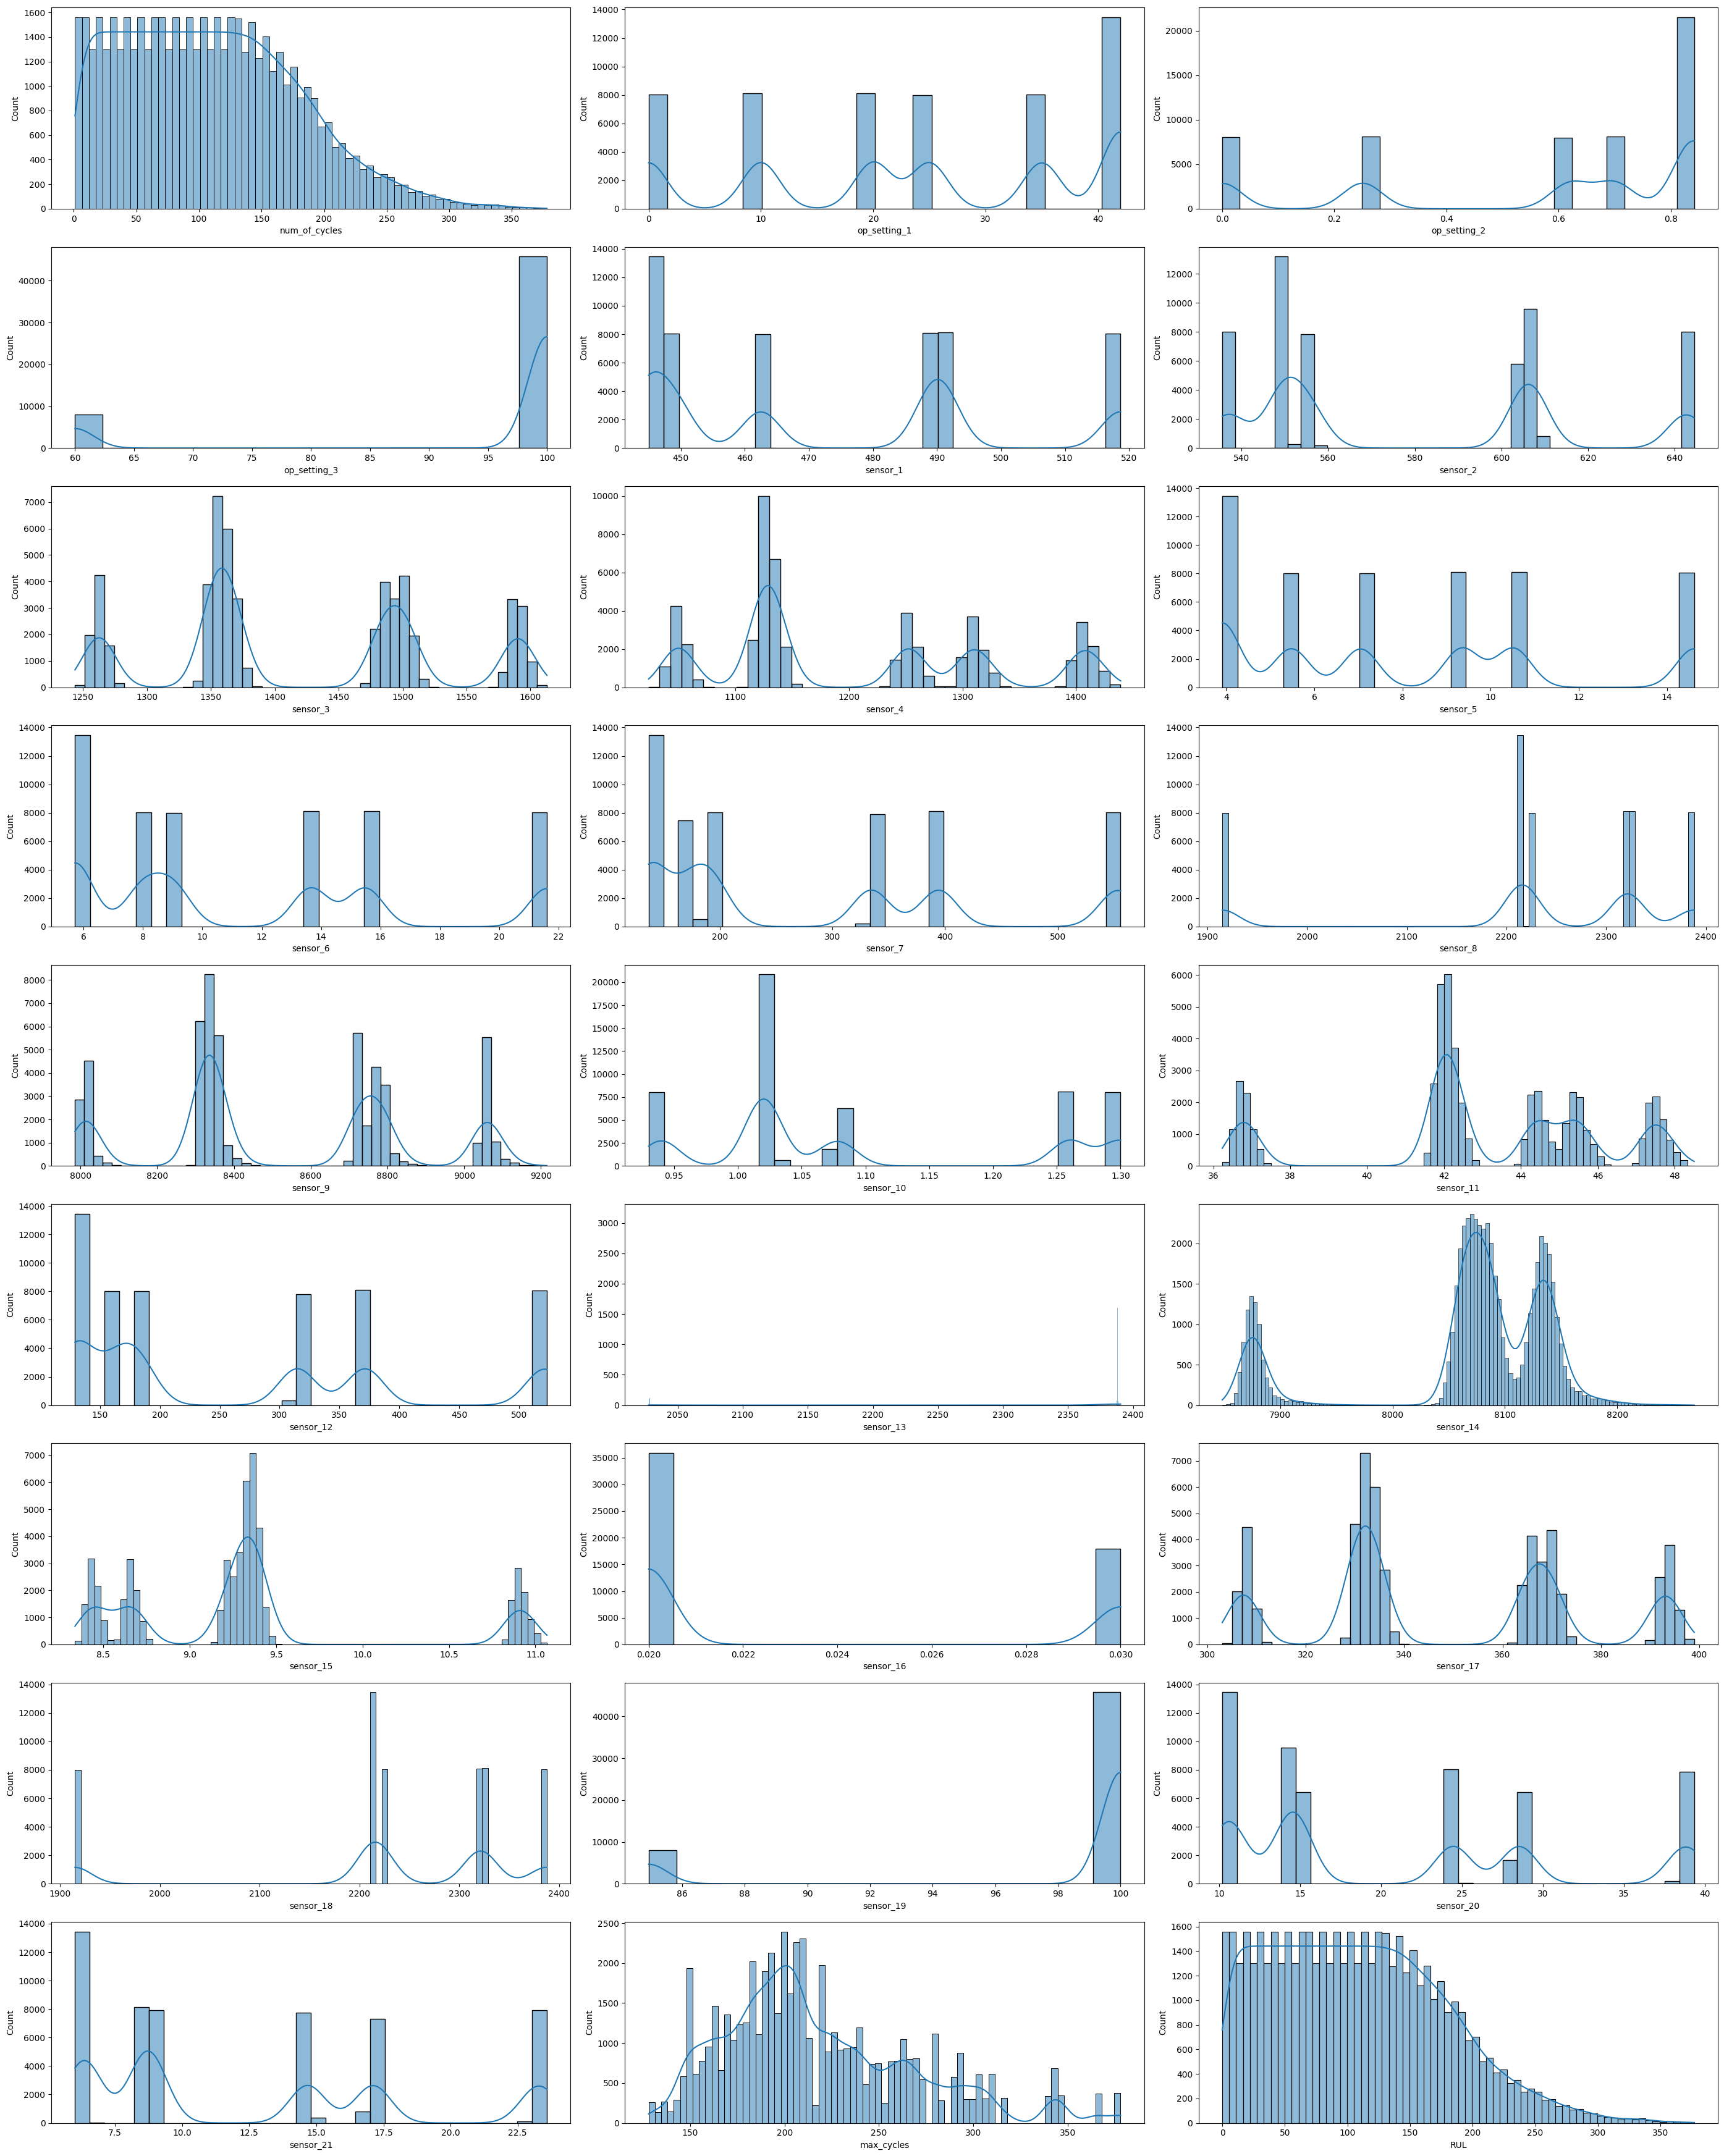

In [ ]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,35))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.histplot(df[col], kde=True)
    plt.tight_layout()

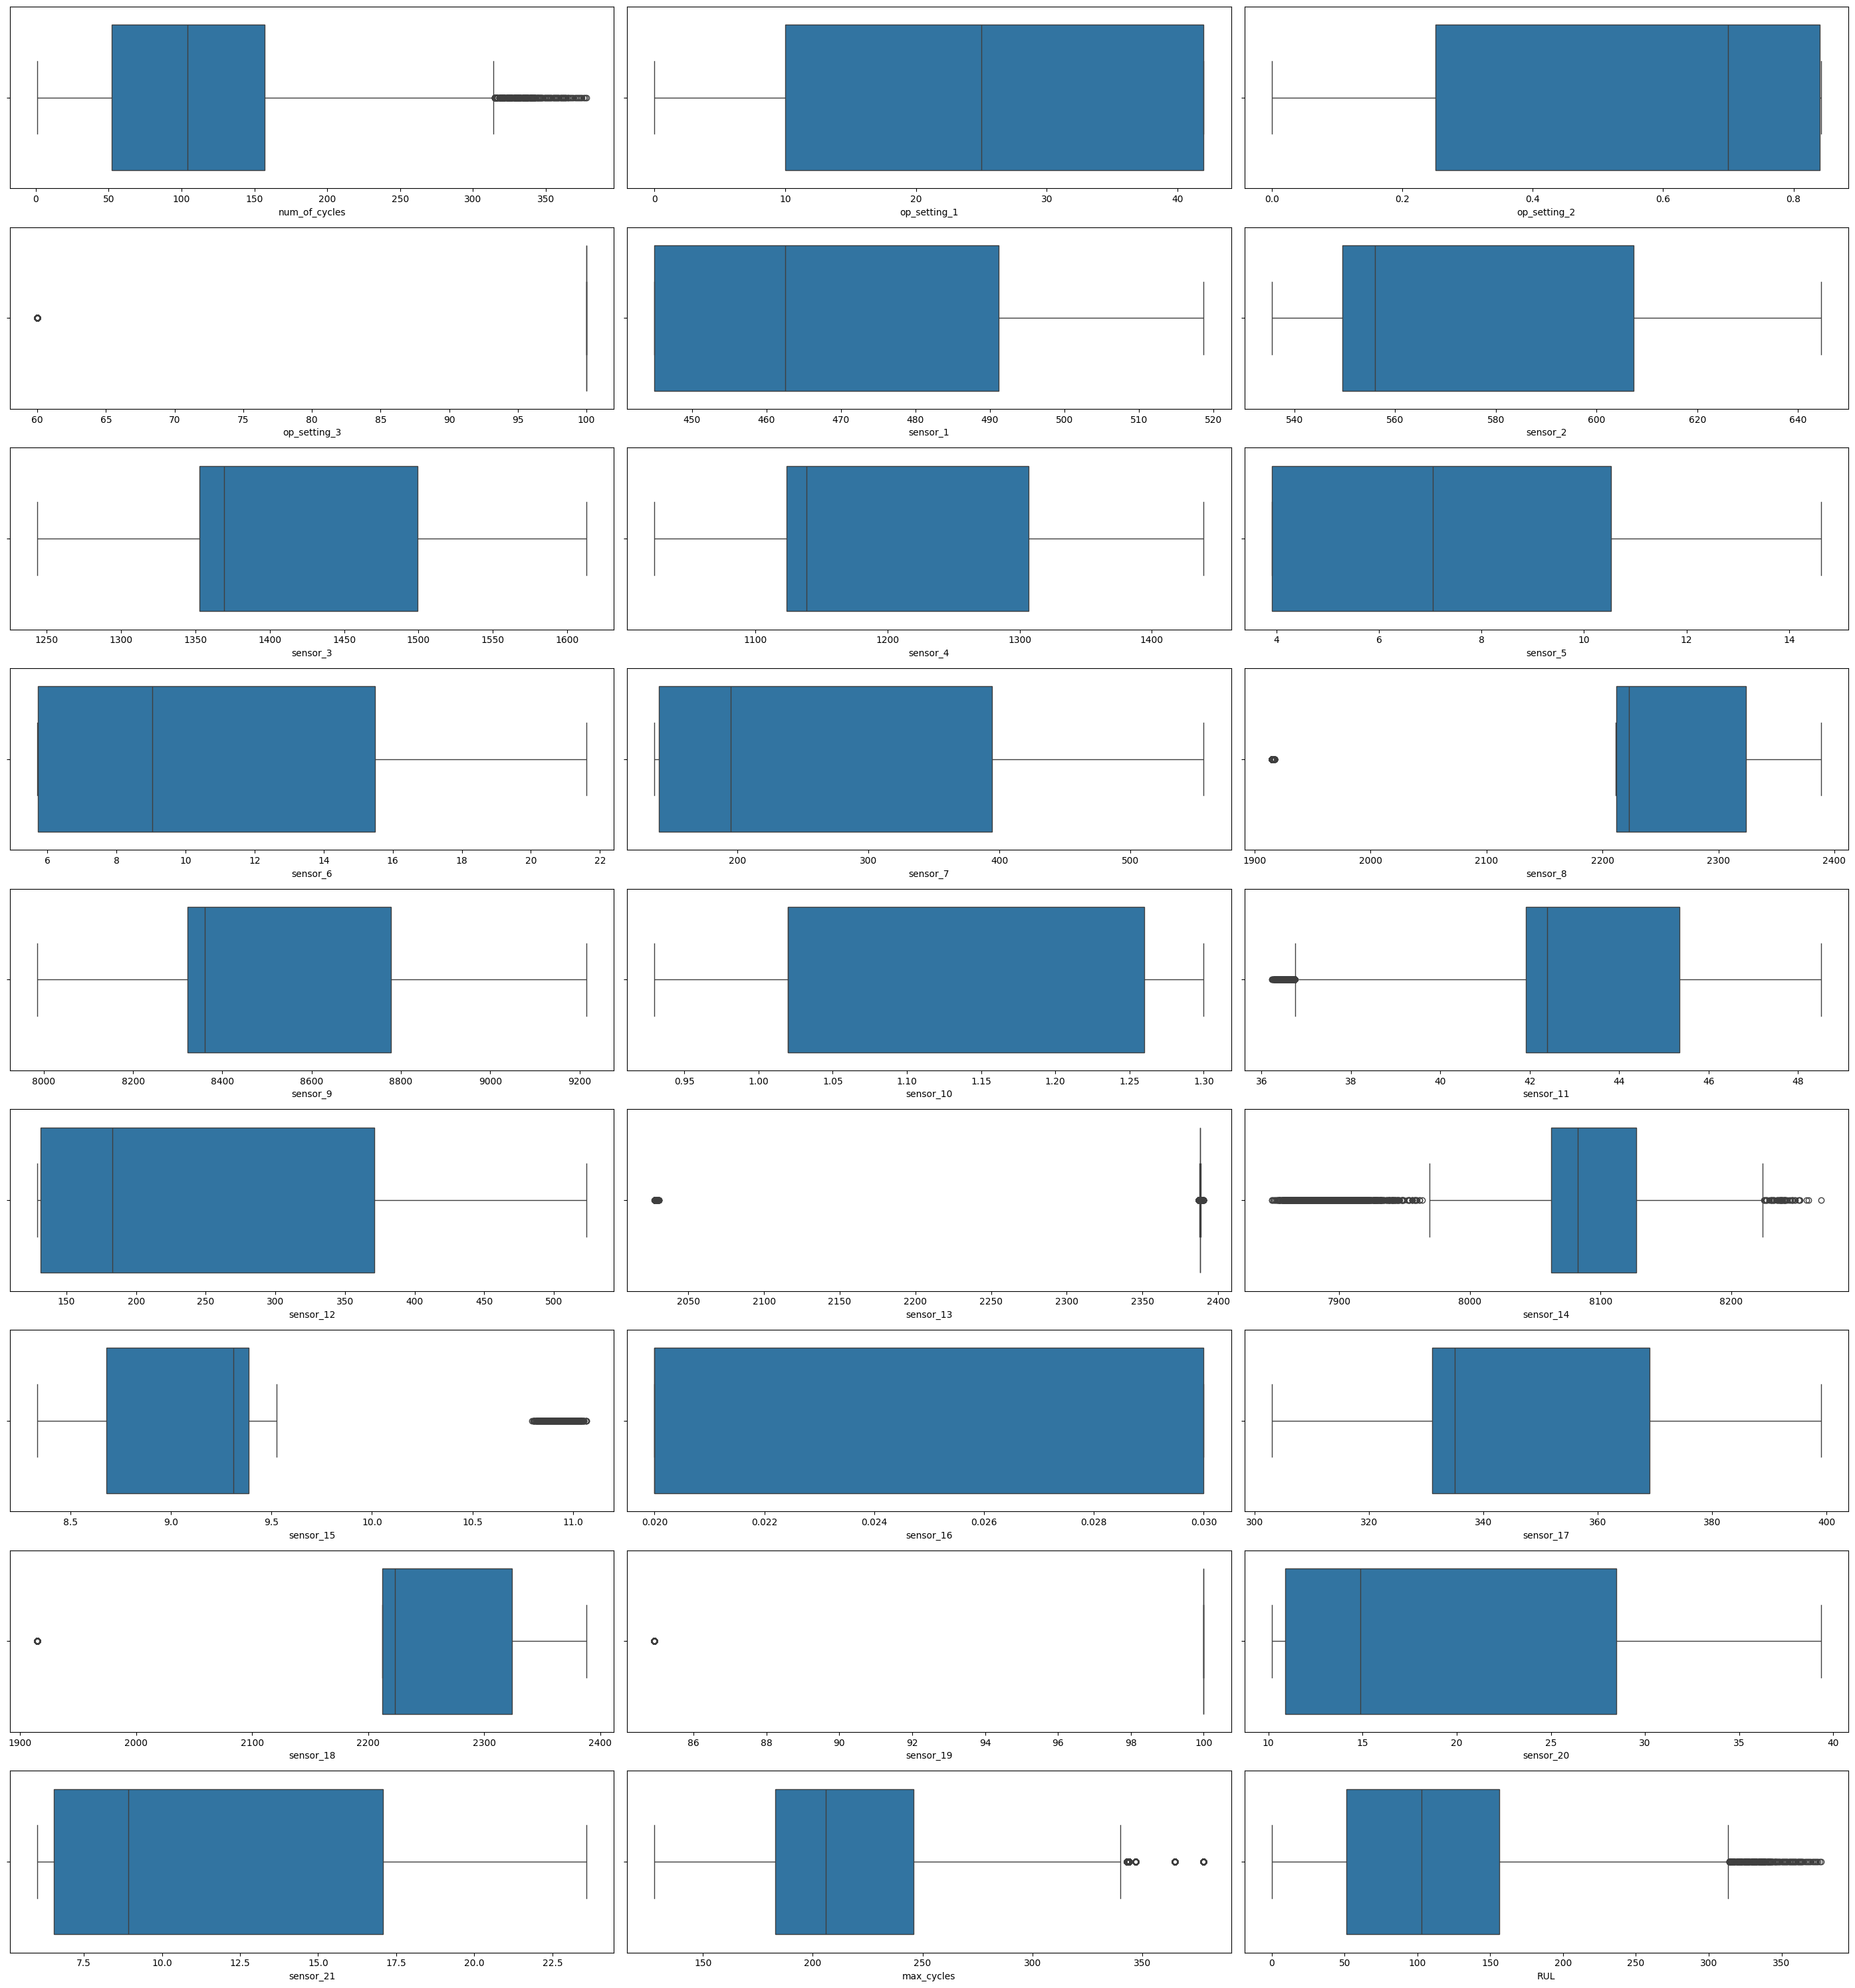

In [ ]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,30))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.boxplot(x=df[col])
    plt.tight_layout()

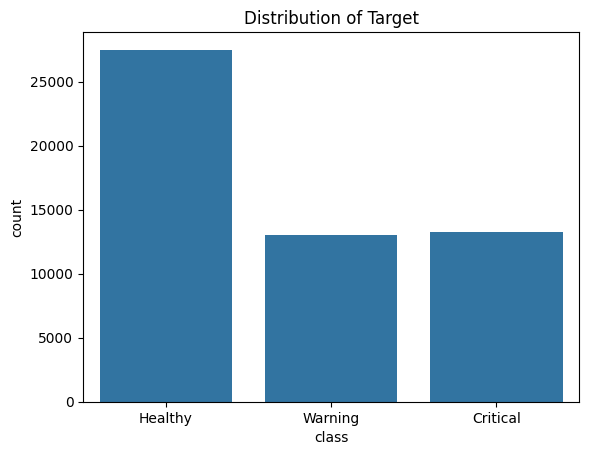

In [ ]:
sns.countplot(x=df['class'])
plt.title("Distribution of Target")
plt.show()

### 2-Bivariate Analysis

In [ ]:
numerical_df= df.drop("class",axis=1)
numerical_df.corr()

,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
num_of_cycles,1.000000,0.000061,0.000775,-0.005045,-0.001037,0.003734,0.024619,0.037092,-0.000536,-0.000711,...,0.071588,0.035144,0.067838,0.025071,-0.004643,-0.005045,-0.006883,-0.006784,0.365089,-0.733385
op_setting_1,0.000061,1.000000,0.943005,-0.028494,-0.964414,-0.867451,-0.787861,-0.840736,-0.987344,-0.976459,...,-0.263386,0.460839,-0.838748,-0.790551,-0.443926,-0.028494,-0.962036,-0.962058,0.001626,0.001127
op_setting_2,0.000775,0.943005,1.000000,-0.065357,-0.884059,-0.808820,-0.759656,-0.836672,-0.932606,-0.928264,...,-0.355460,0.520012,-0.888614,-0.762703,-0.438602,-0.065357,-0.920771,-0.920777,0.001113,0.000038
op_setting_3,-0.005045,-0.028494,-0.065357,1.000000,0.164342,0.480081,0.620847,0.544570,0.113641,0.198099,...,0.927381,-0.884177,0.295219,0.617191,0.903000,1.000000,0.276550,0.276486,0.000974,0.005757
sensor_1,-0.001037,-0.964414,-0.884059,0.164342,1.000000,0.944089,0.870963,0.898002,0.986372,0.986424,...,0.352781,-0.542747,0.793787,0.873265,0.572175,0.164342,0.977704,0.977718,-0.001438,-0.000014
sensor_2,0.003734,-0.867451,-0.808820,0.480081,0.944089,1.000000,0.982225,0.981047,0.915807,0.944071,...,0.623963,-0.777956,0.805279,0.983065,0.810315,0.480081,0.962424,0.962416,-0.001627,-0.004922
sensor_3,0.024619,-0.787861,-0.759656,0.620847,0.870963,0.982225,1.000000,0.989565,0.842950,0.884794,...,0.751865,-0.875931,0.804819,0.998680,0.895448,0.620847,0.917143,0.917125,-0.003173,-0.026936
sensor_4,0.037092,-0.840736,-0.836672,0.544570,0.898002,0.981047,0.989565,1.000000,0.884241,0.919683,...,0.715494,-0.846728,0.859129,0.990213,0.843649,0.544570,0.946478,0.946469,-0.005315,-0.040972
sensor_5,-0.000536,-0.987344,-0.932606,0.113641,0.986372,0.915807,0.842950,0.884241,1.000000,0.996311,...,0.330512,-0.525386,0.824093,0.845625,0.523829,0.113641,0.985714,0.985727,-0.001761,-0.000750
sensor_6,-0.000711,-0.976459,-0.928264,0.198099,0.986424,0.944071,0.884794,0.919683,0.996311,1.000000,...,0.407504,-0.595564,0.840331,0.887137,0.594049,0.198099,0.996356,0.996363,-0.001643,-0.000489


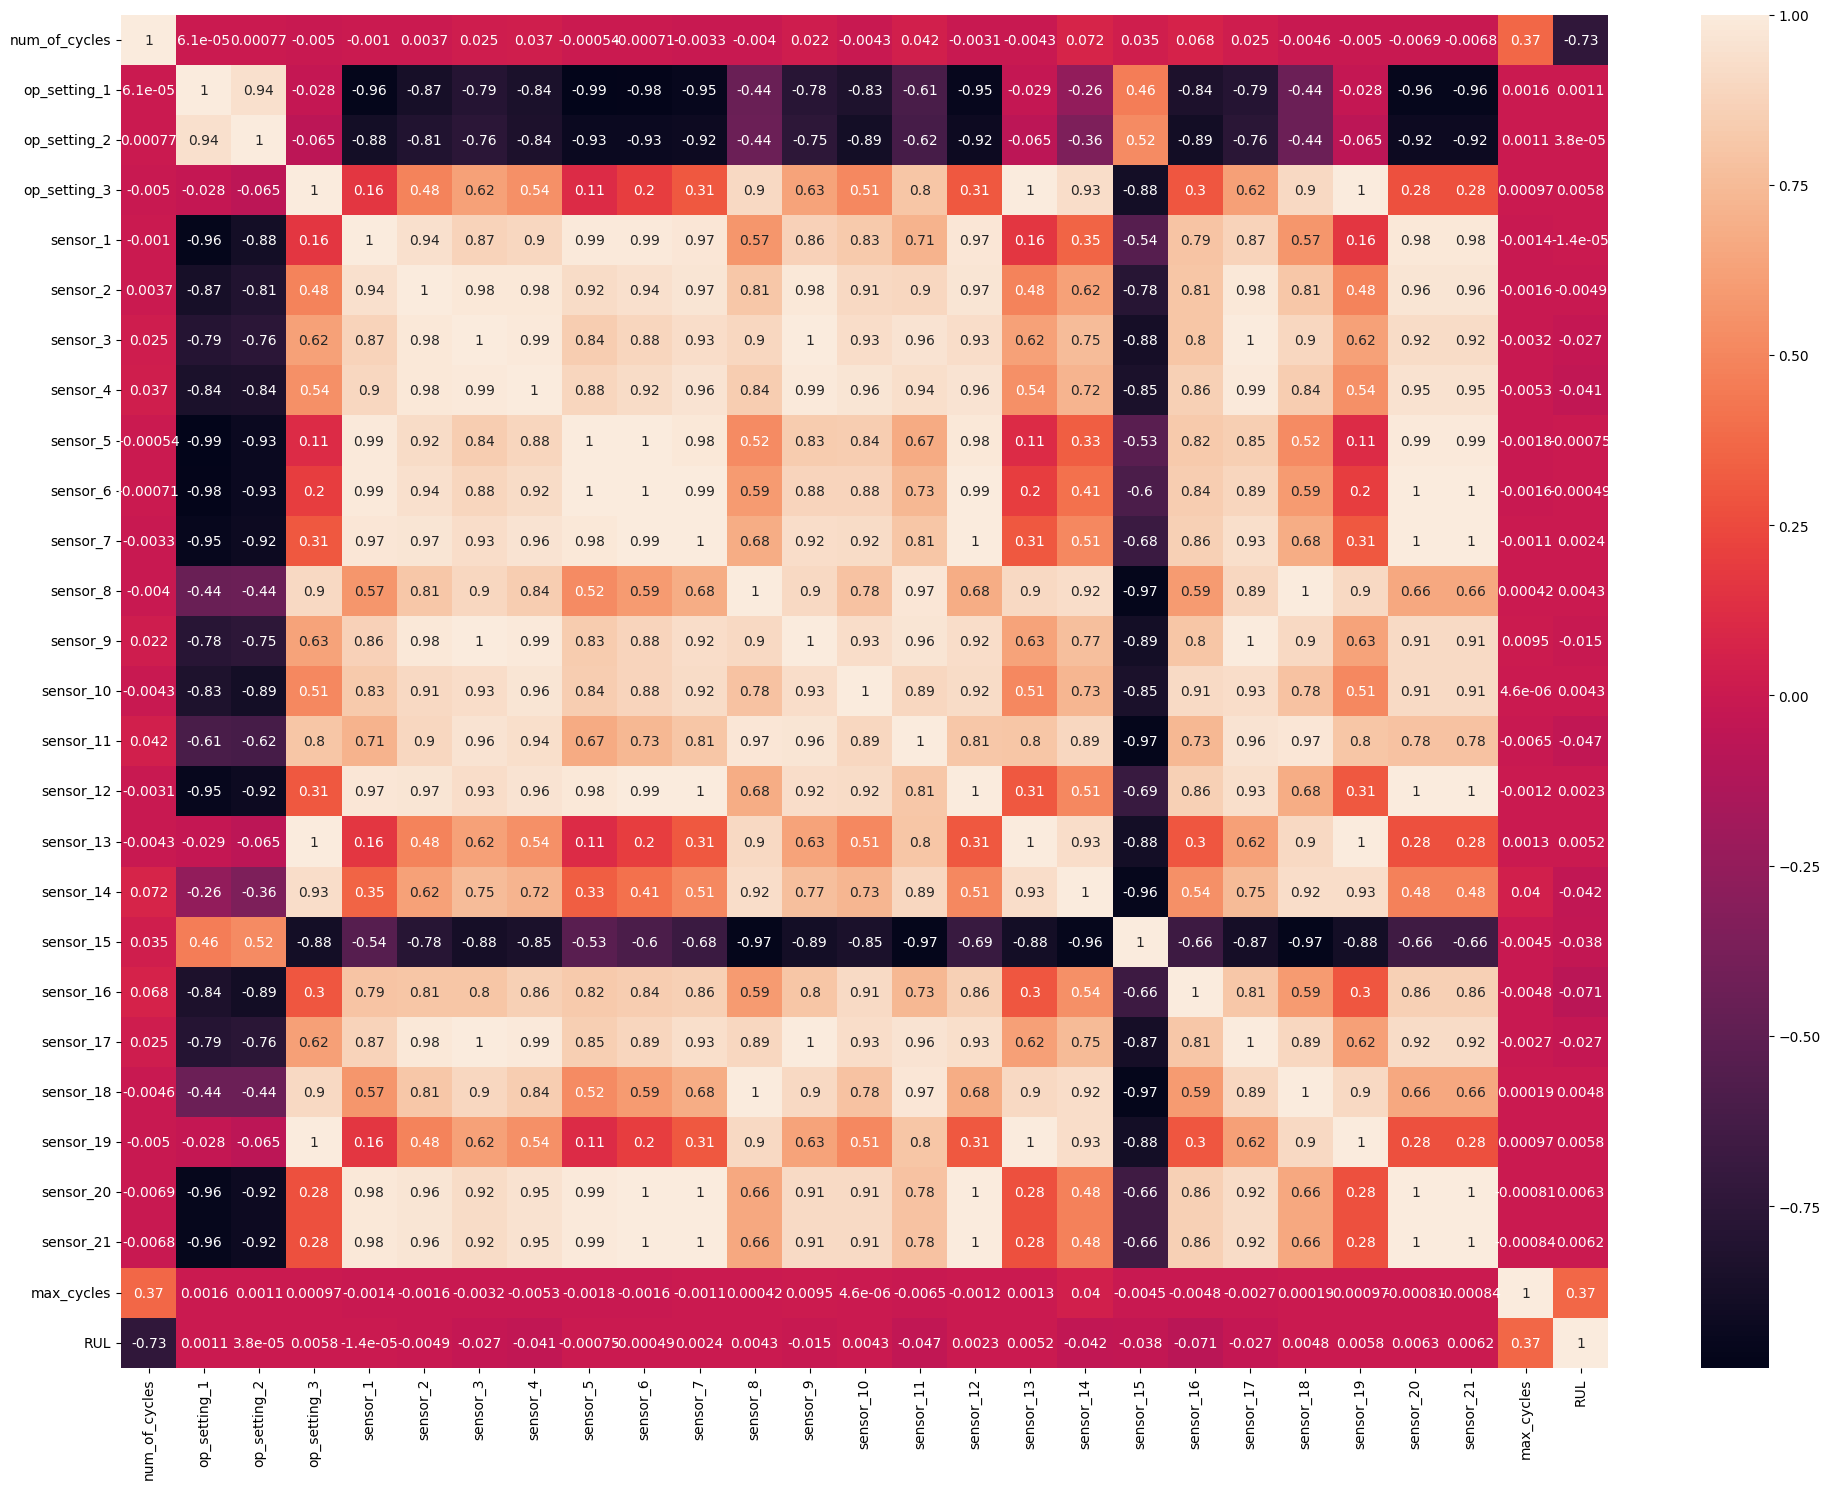

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(numerical_df.corr(), annot=True)
plt.tight_layout()
plt.show()

In [ ]:
numerical_df.corr()['RUL'].sort_values()

,RUL
num_of_cycles,-0.733385
sensor_16,-0.071345
sensor_11,-0.046946
sensor_14,-0.042323
sensor_4,-0.040972
sensor_15,-0.038455
sensor_17,-0.027026
sensor_3,-0.026936
sensor_9,-0.015300
sensor_2,-0.004922


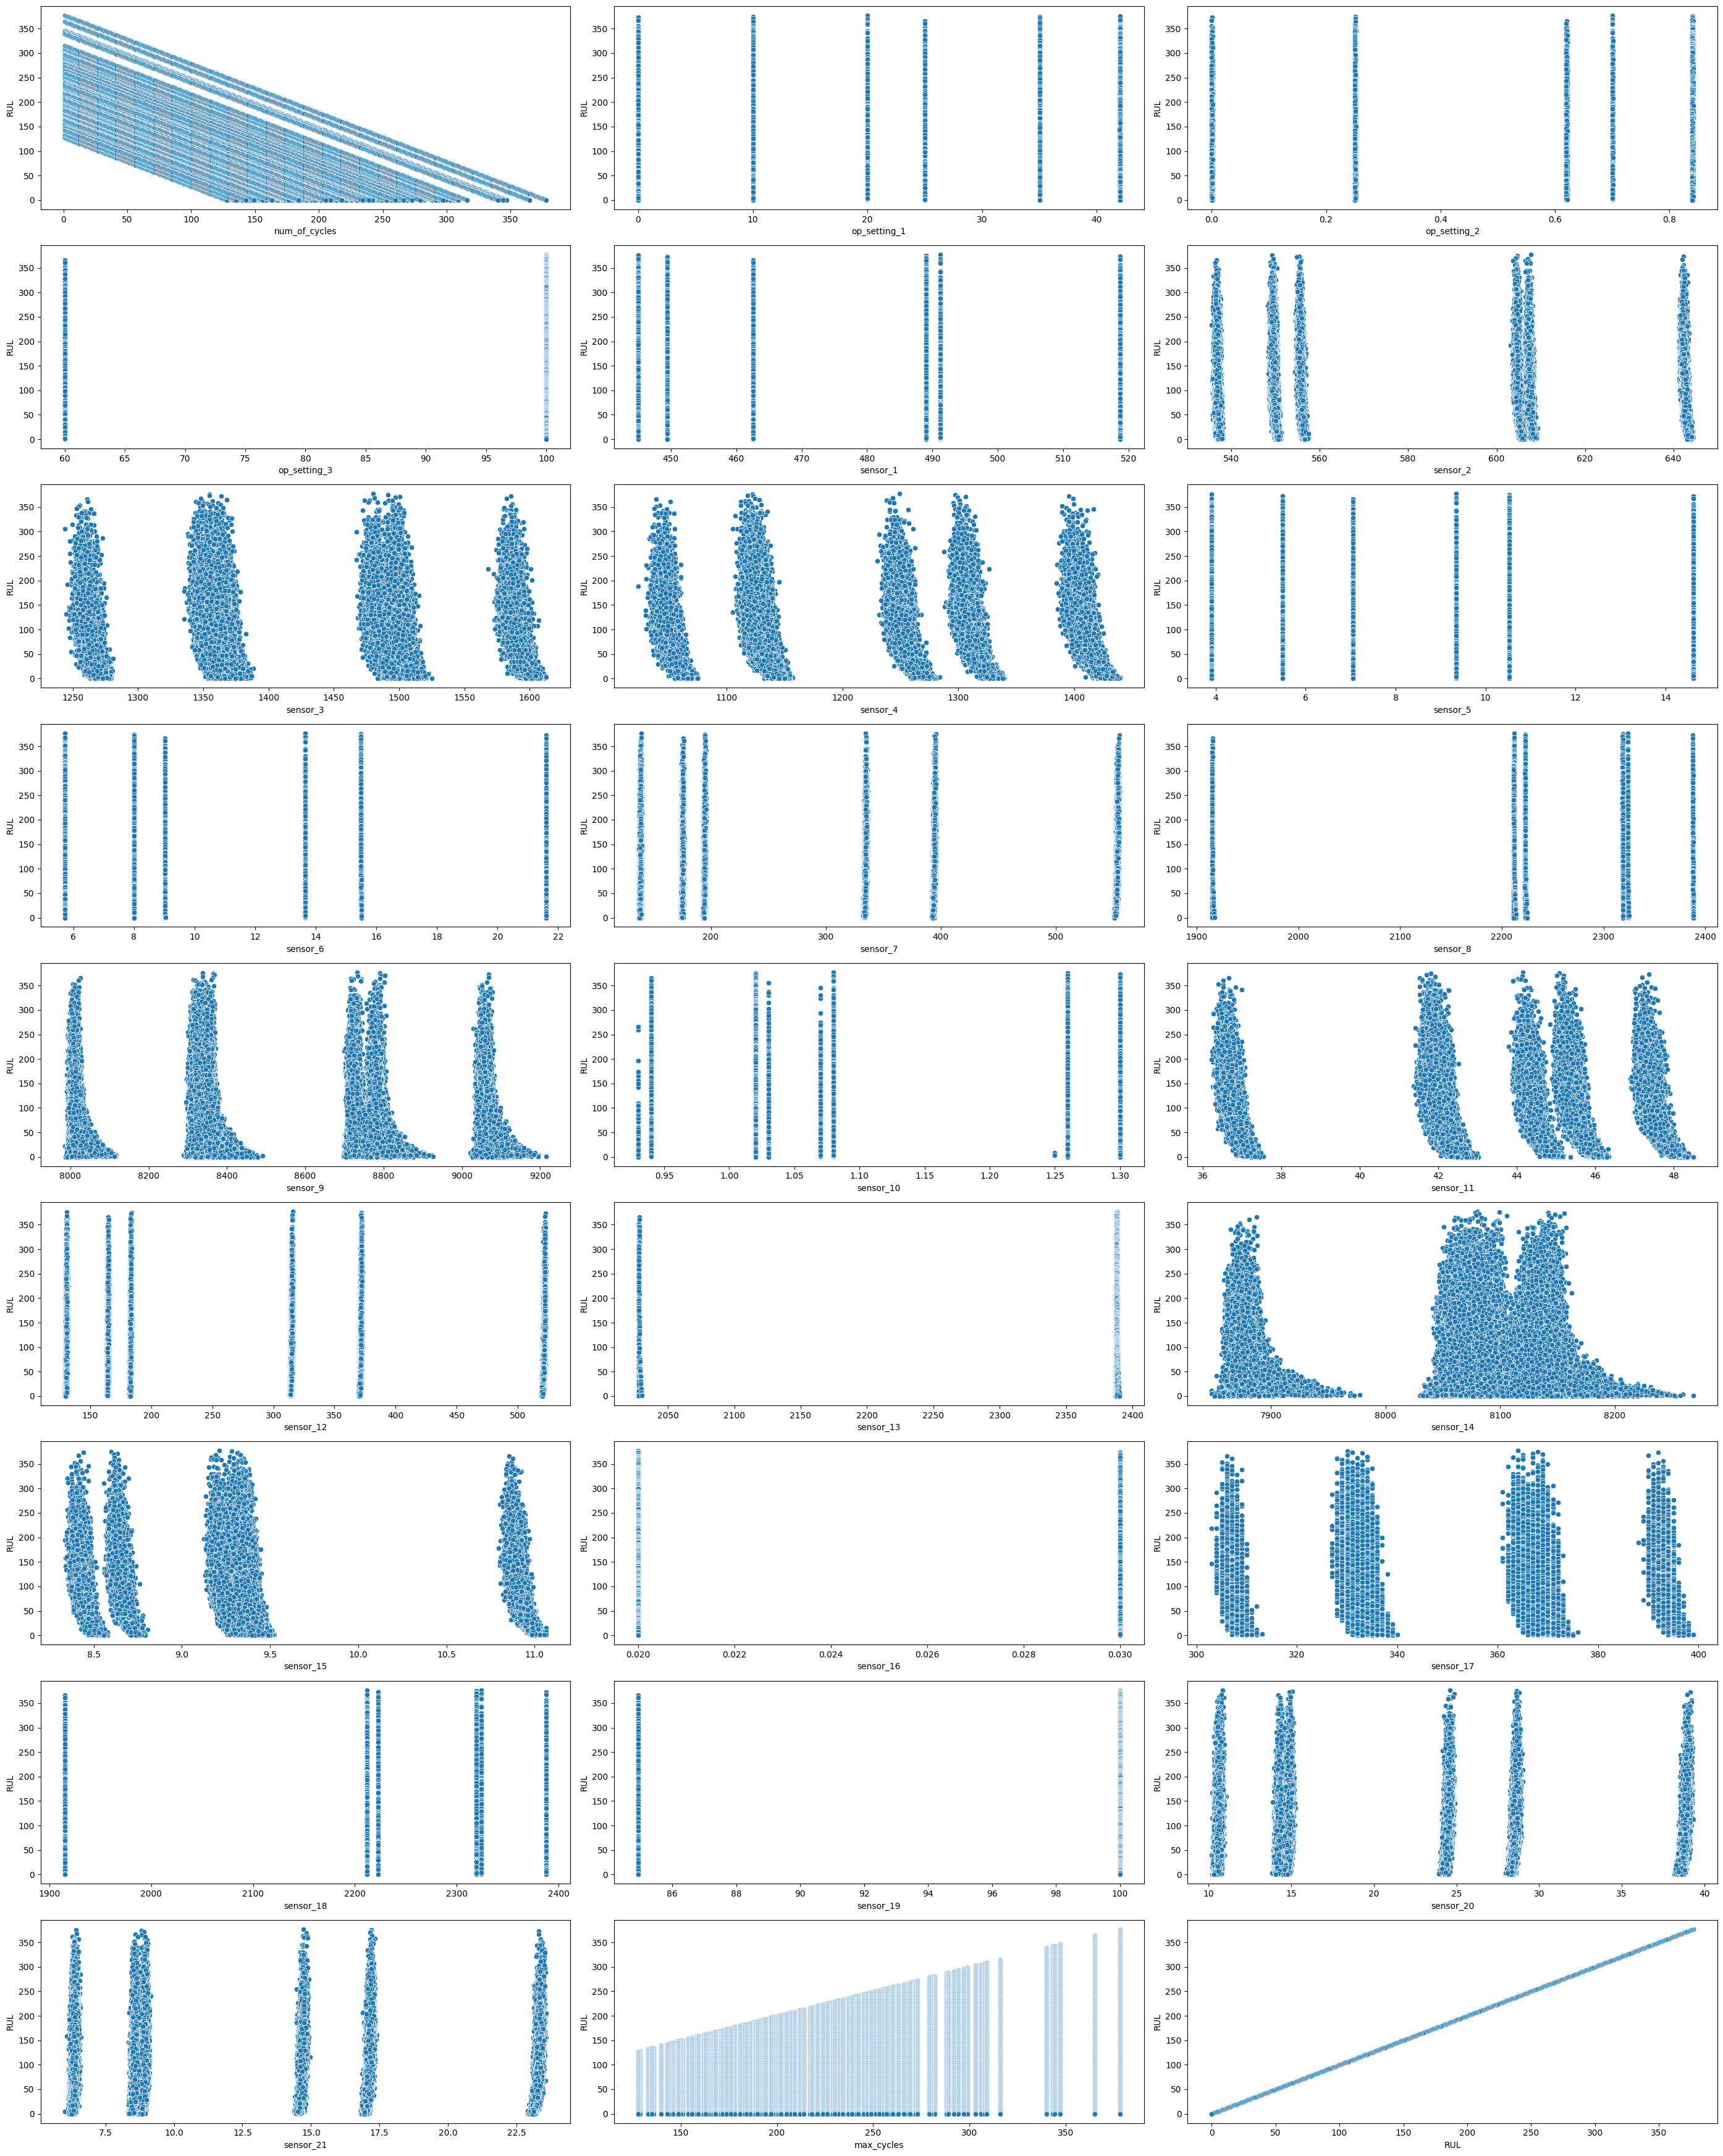

In [ ]:
plt.figure(figsize=(28,35))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.scatterplot(data=df,x=col,y="RUL")
    plt.tight_layout()

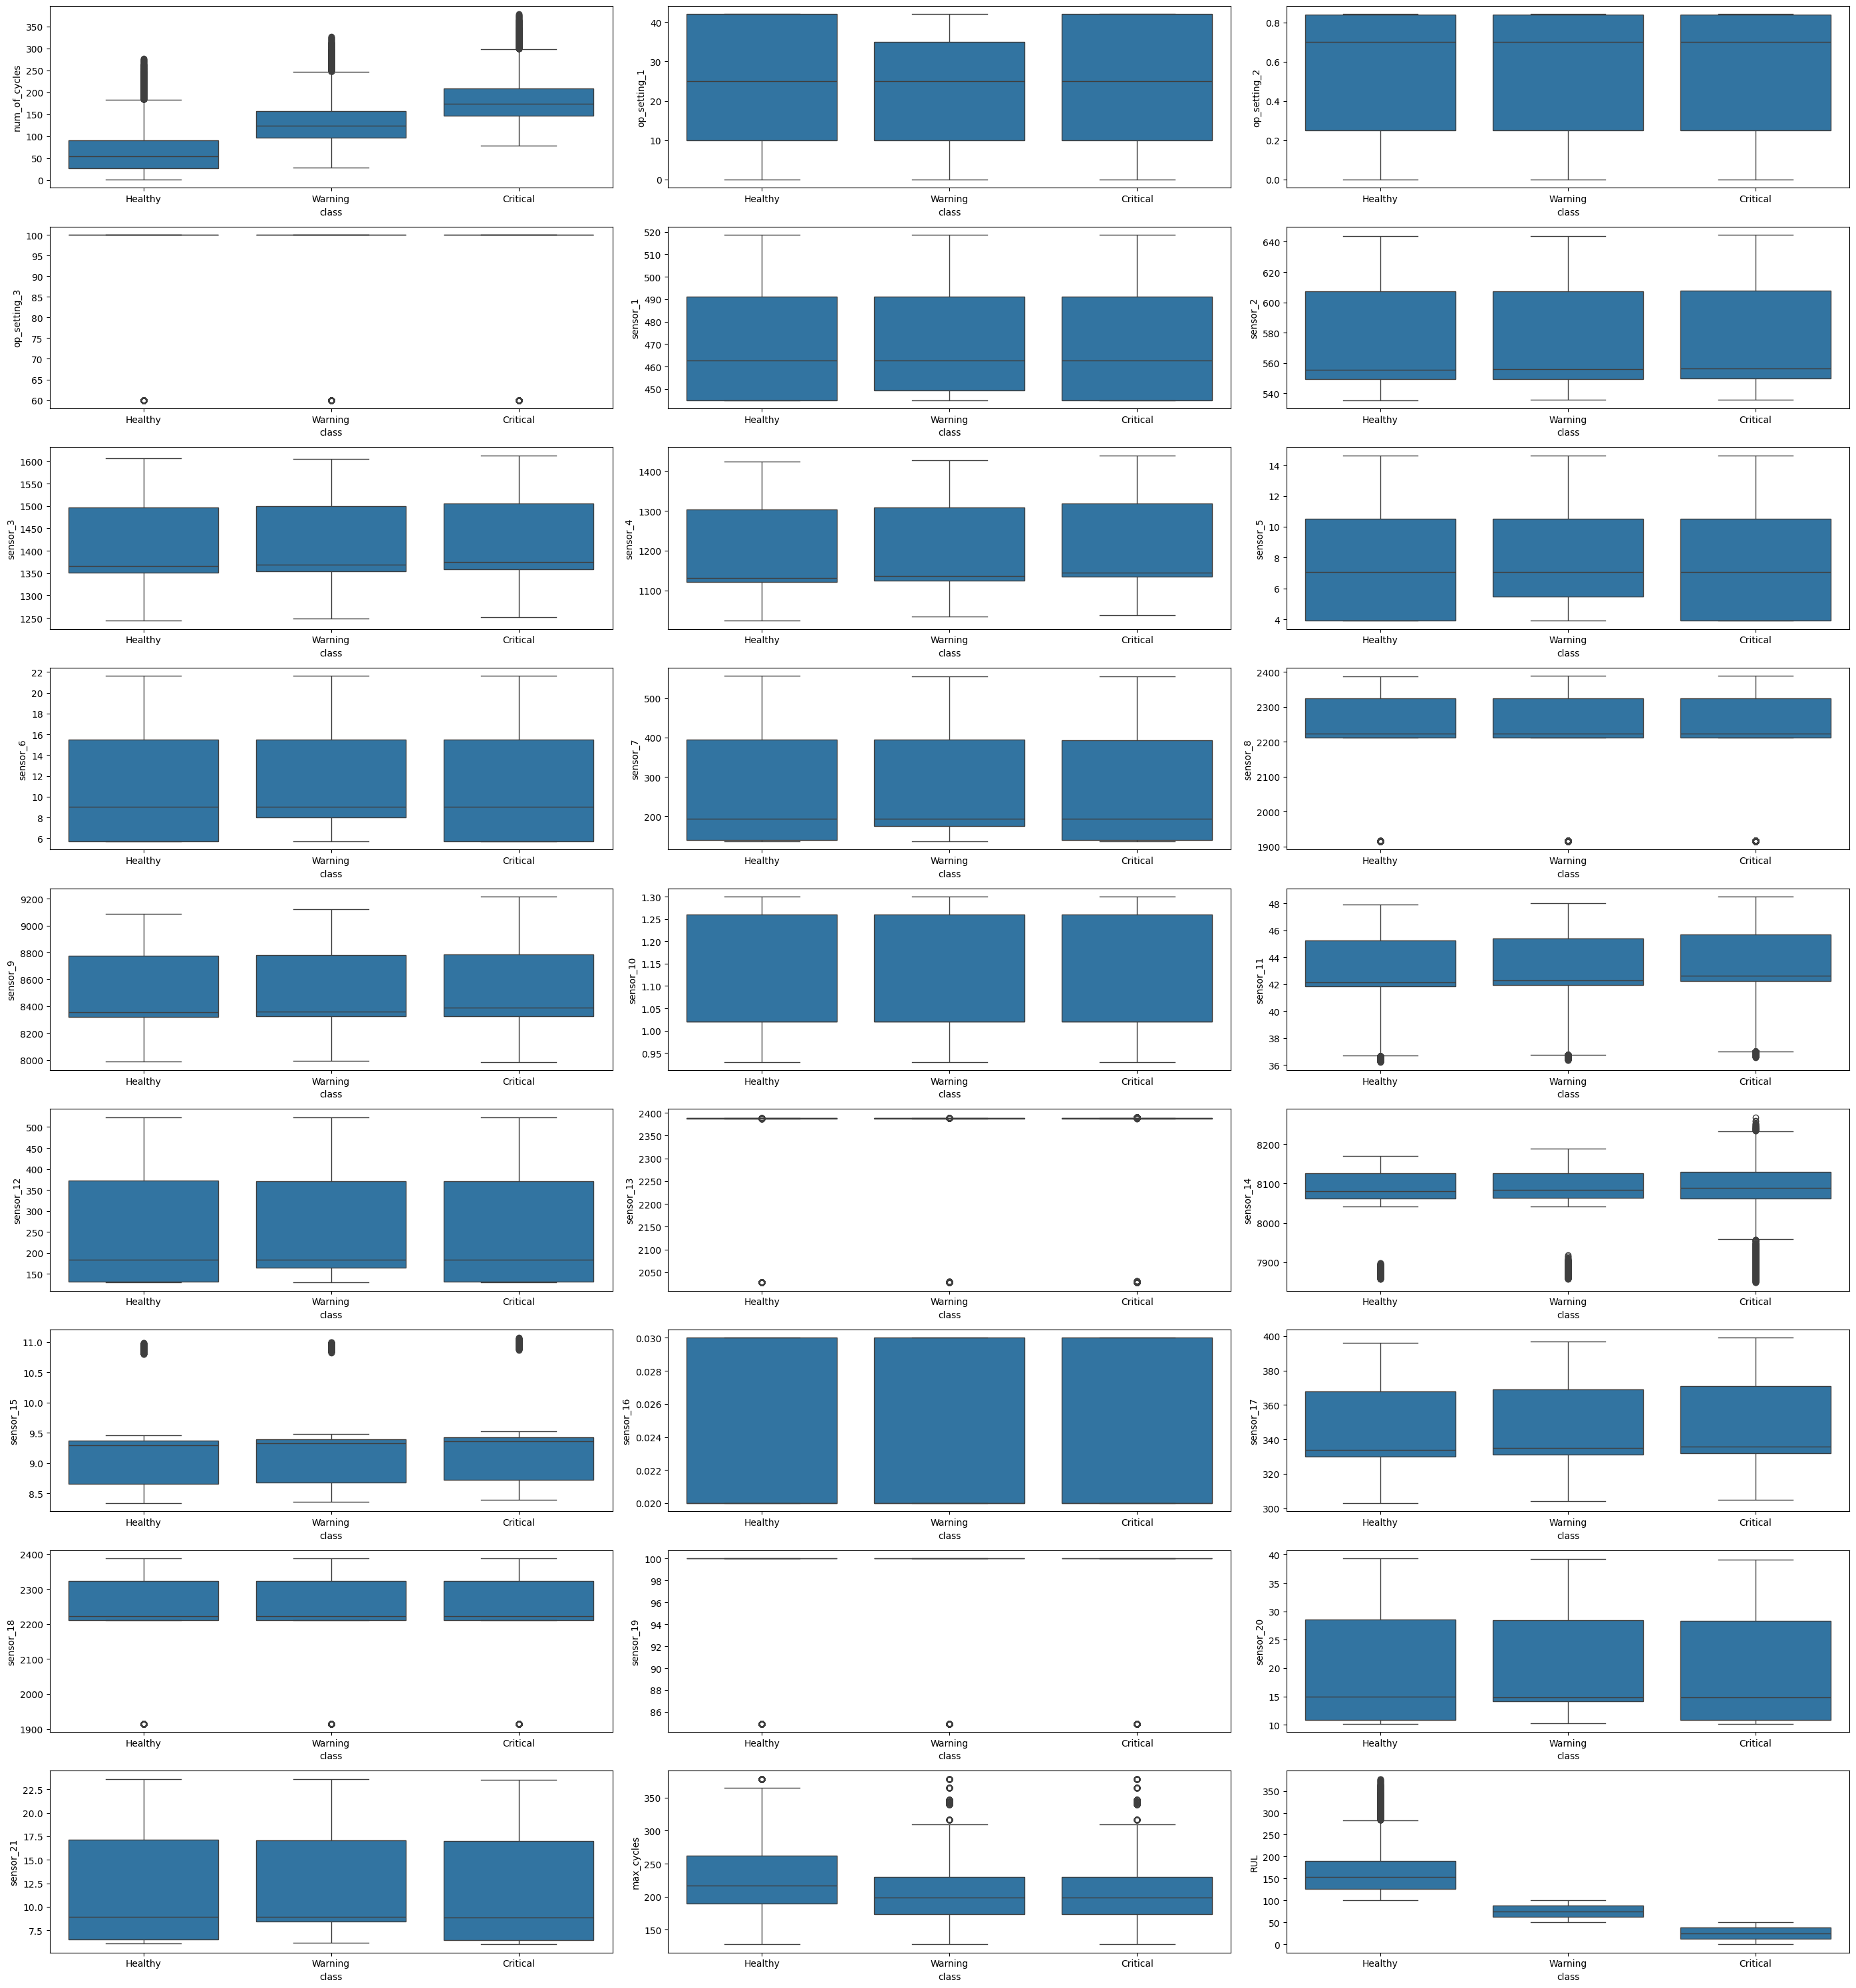

In [ ]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,30))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.boxplot(data=df,x="class",y=col)
    plt.tight_layout()

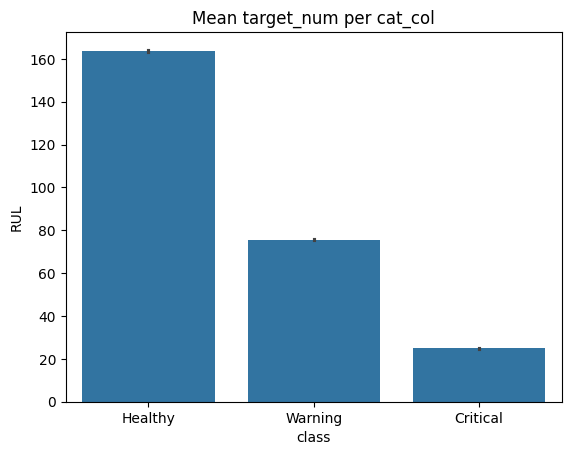

In [ ]:
sns.barplot(data=df, x='class', y='RUL', estimator='mean')
plt.title('Mean target_num per cat_col')
plt.show()

In [ ]:
df.groupby('class').agg(["min","max","mean","median","std"])

num_of_cycles                                    op_setting_1  \
                   min  max        mean median        std          min   
class                                                                    
Critical            78  378  181.765385  174.0  48.959207          0.0   
Healthy              1  277   63.691541   54.0  47.230609          0.0   
Warning             28  327  131.265385  124.0  48.873206          0.0   

                                                 ... max_cycles       \
             max       mean   median        std  ...        min  max   
class                                            ...                   
Critical  42.008  24.048179  25.0014  14.735261  ...        128  378   
Healthy   42.008  24.018746  25.0014  14.783568  ...        128  378   
Warning   42.008  23.903774  25.0012  14.683907  ...        128  378   

                                        RUL                                     
                mean median        std  min  max        mean median        std  
class                                                                           
Critical  206.765385  199.0  46.693907    0   50   25.000000   25.0  14.720157  
Healthy   227.381373  217.0  51.956459  101  377  163.689832  154.0  47.232028  
Warning   206.765385  199.0  46.693942   51  100   75.500000   75.5  14.431425  

[3 rows x 135 columns]

### 3-Multivariate Analysis

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Clean data before VIF
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fix infinite and missing values
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 2. Calculate VIF
numerical_cols = df.select_dtypes("number").columns.drop("RUL")
X = df[numerical_cols]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF Results:")
print(vif_data.sort_values("VIF", ascending=False))
print("\n" + "="*50)

# 3. Optional: Identify high VIF features
high_vif = vif_data[vif_data["VIF"] > 10]
if not high_vif.empty:
    print("Features with high multicollinearity (VIF > 10):")
    print(high_vif)

VIF Results:
          feature           VIF
3    op_setting_3  7.358643e+10
22      sensor_19  4.047743e+10
21      sensor_18  3.788686e+09
4        sensor_1  7.406117e+08
11       sensor_8  1.253360e+07
16      sensor_13  8.562120e+06
8        sensor_5  6.596283e+06
1    op_setting_1  4.558821e+06
9        sensor_6  2.297771e+06
2    op_setting_2  1.980629e+05
15      sensor_12  1.695125e+05
10       sensor_7  1.141157e+05
5        sensor_2  1.452329e+04
24      sensor_21  9.207714e+03
23      sensor_20  9.011809e+03
13      sensor_10  4.701562e+03
12       sensor_9  4.299732e+03
18      sensor_15  1.111218e+03
20      sensor_17  7.989007e+02
14      sensor_11  7.772975e+02
7        sensor_4  7.617684e+02
6        sensor_3  6.709071e+02
17      sensor_14  3.468533e+02
19      sensor_16  1.043824e+01
0   num_of_cycles  3.287838e+00
25     max_cycles  1.524116e+00

Features with high multicollinearity (VIF > 10):
         feature           VIF
1   op_setting_1  4.558821e+06
2   op_sett

In [ ]:

# Identify numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns:")
print(num_cols)

Numeric columns:
Index(['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL'],
      dtype='object')


In [ ]:

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
print("Outliers detected by IQR method per column:")
print(outliers_iqr)


Outliers detected by IQR method per column:
num_of_cycles     235
op_setting_1        0
op_setting_2        0
op_setting_3     8002
sensor_1            0
sensor_2            0
sensor_3            0
sensor_4            0
sensor_5            0
sensor_6            0
sensor_7            0
sensor_8         8002
sensor_9            0
sensor_10           0
sensor_11        3433
sensor_12           0
sensor_13        9640
sensor_14        8049
sensor_15        8002
sensor_16           0
sensor_17           0
sensor_18        8002
sensor_19        8002
sensor_20           0
sensor_21           0
max_cycles       1777
RUL               235
dtype: int64


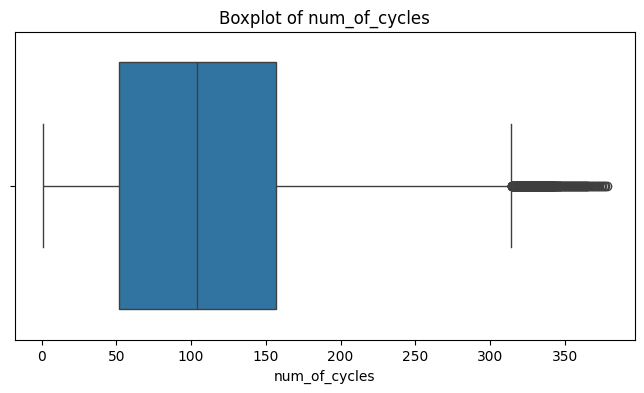

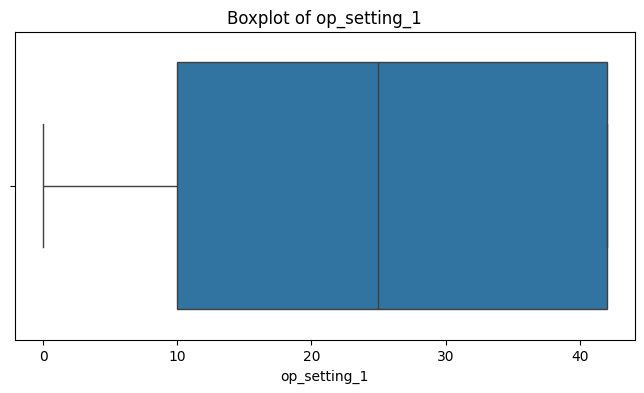

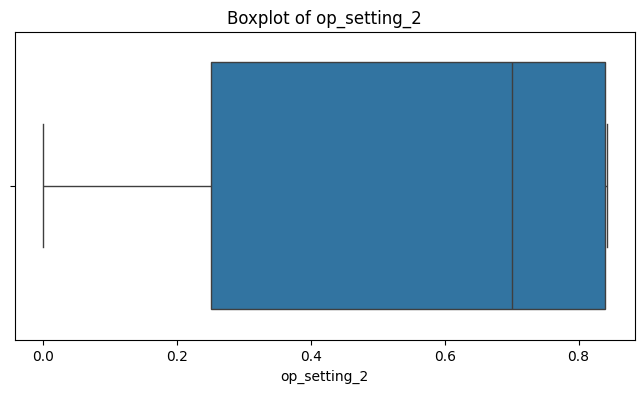

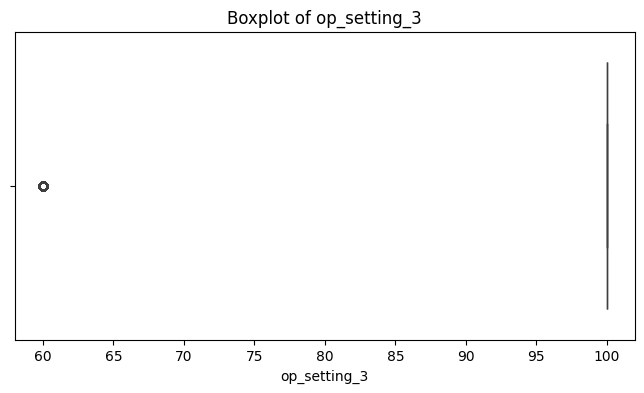

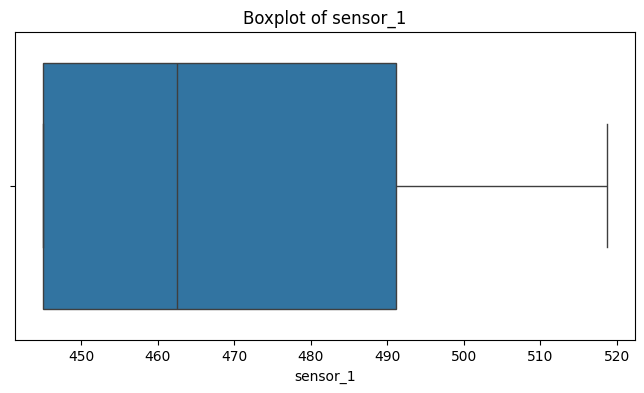

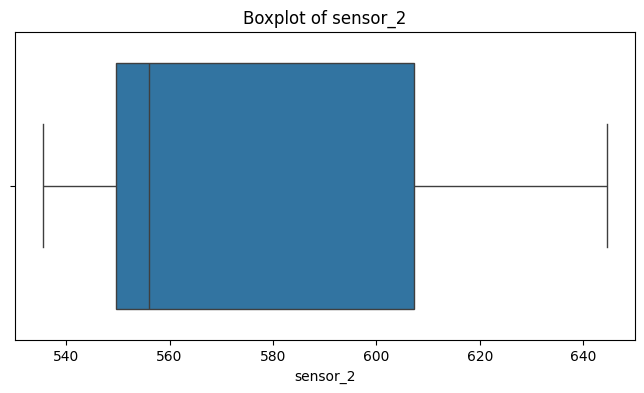

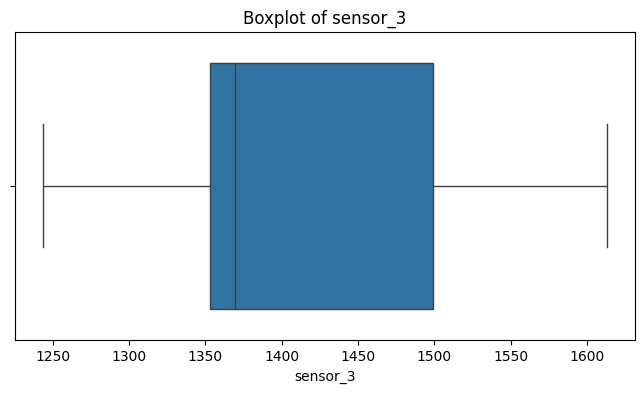

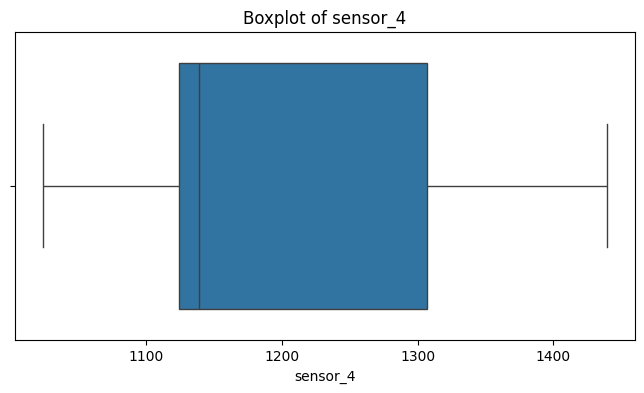

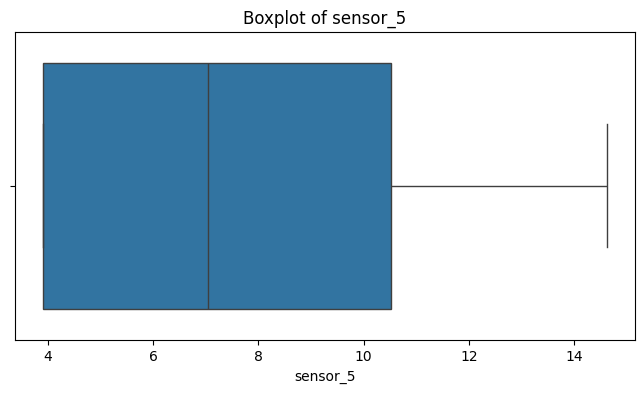

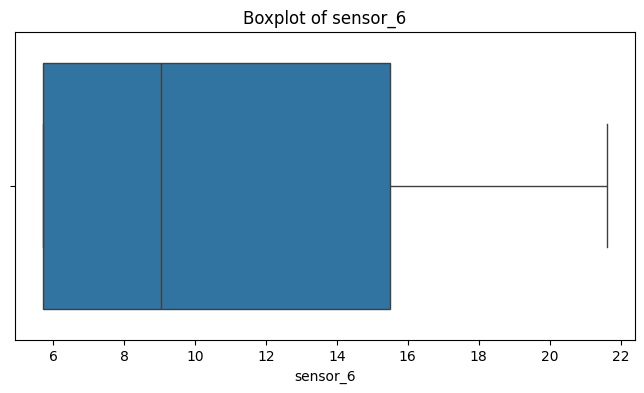

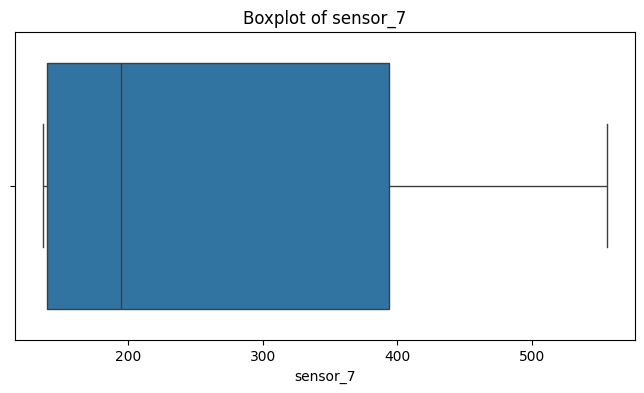

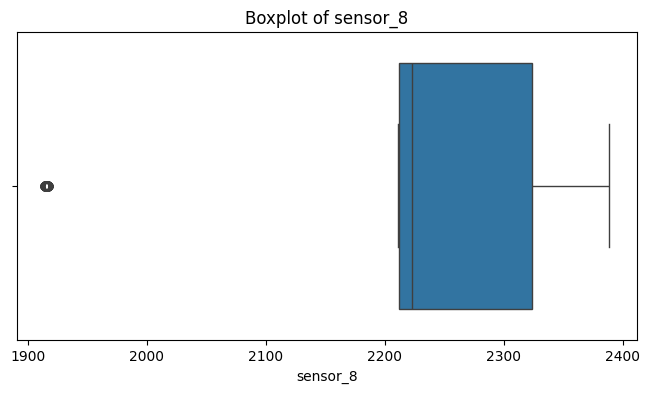

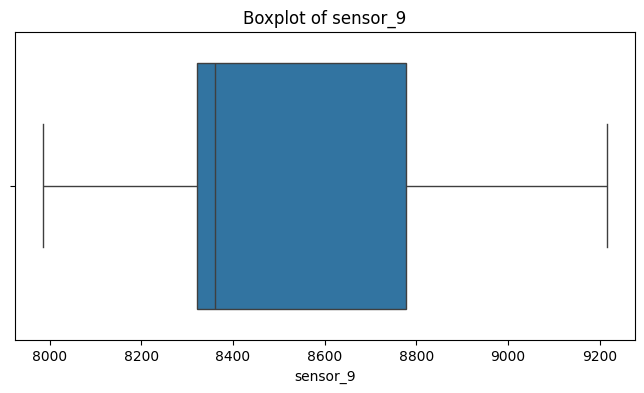

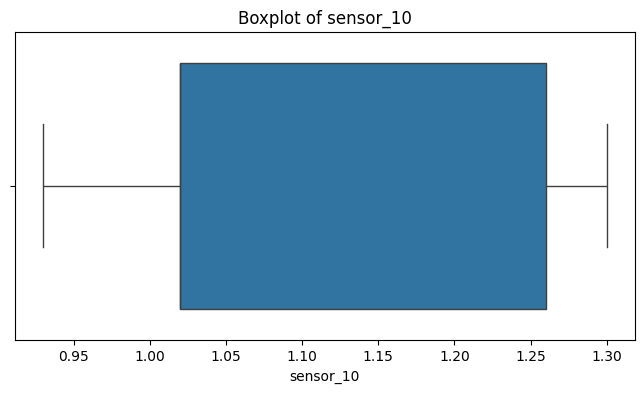

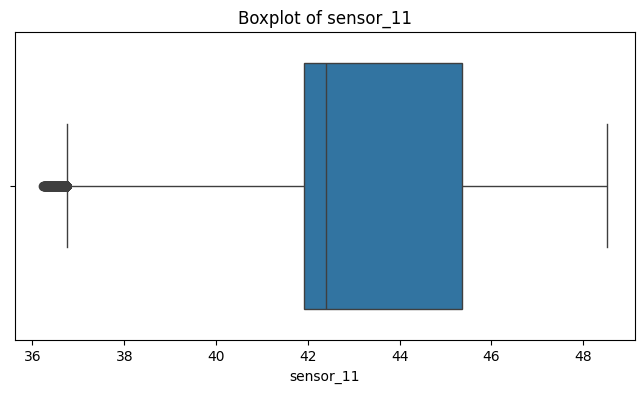

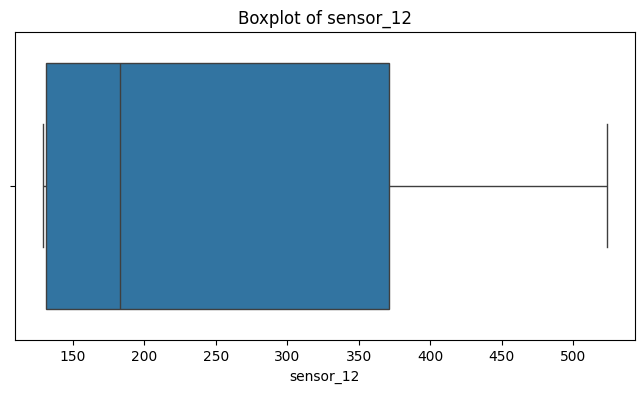

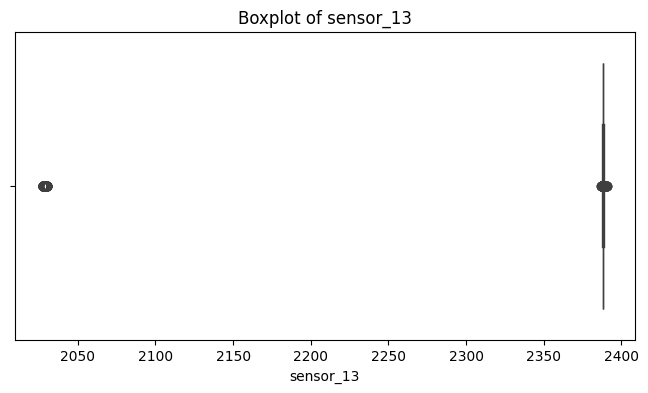

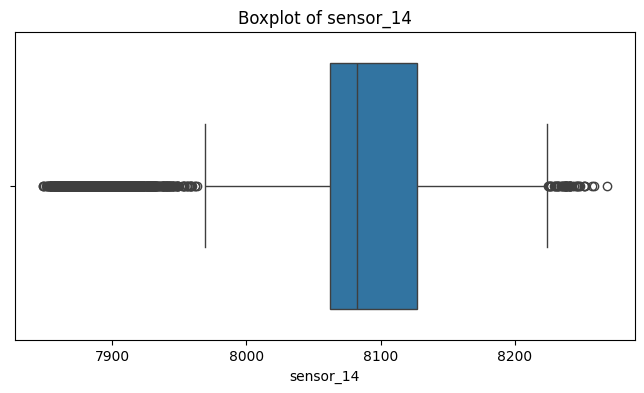

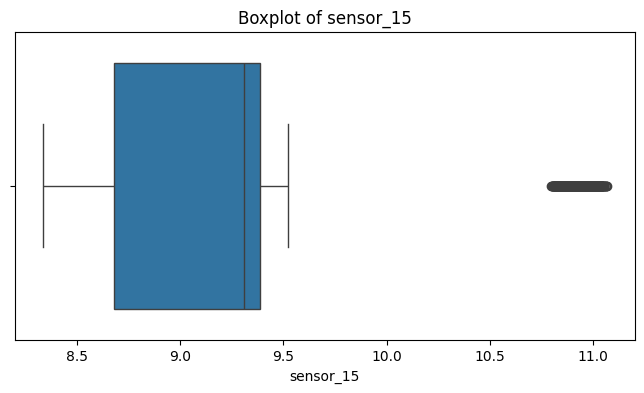

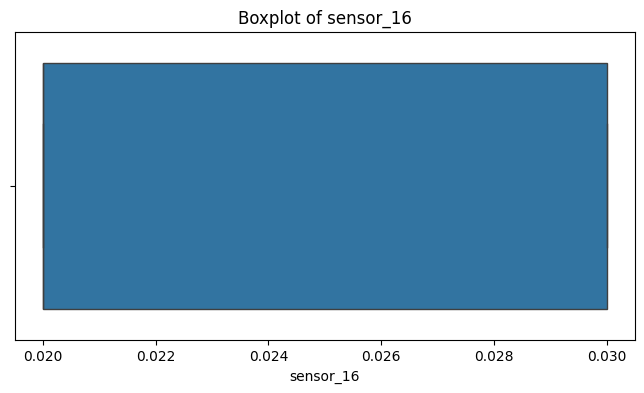

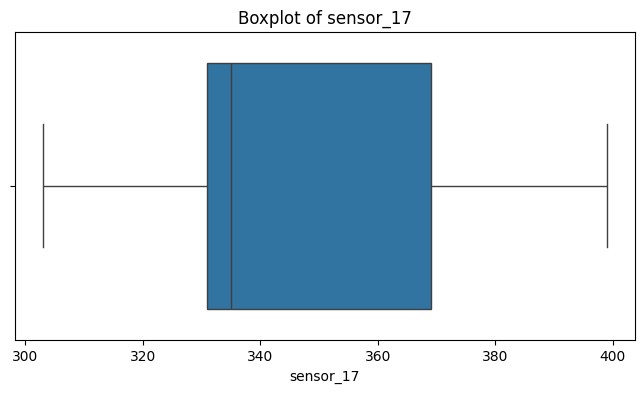

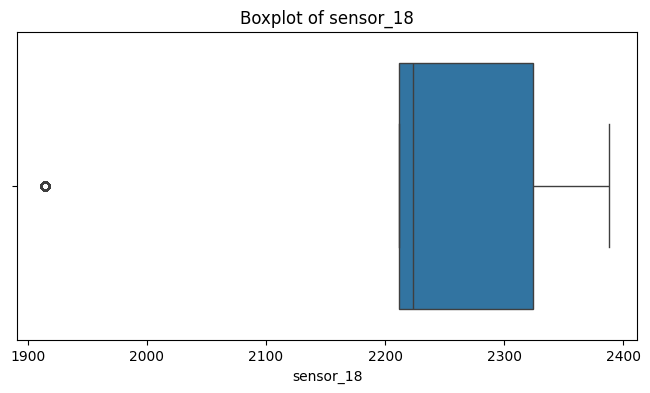

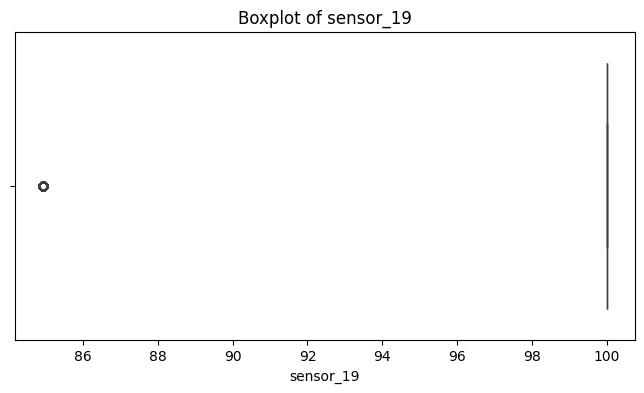

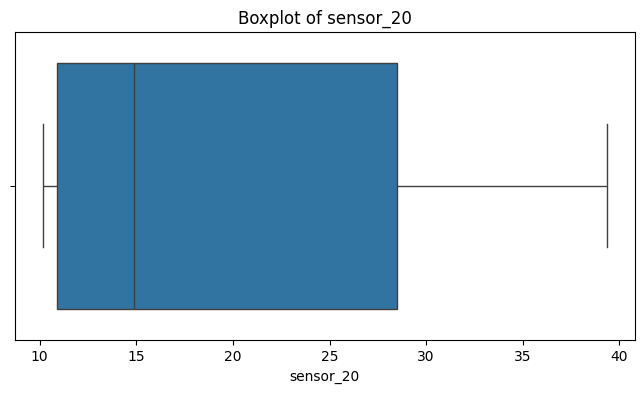

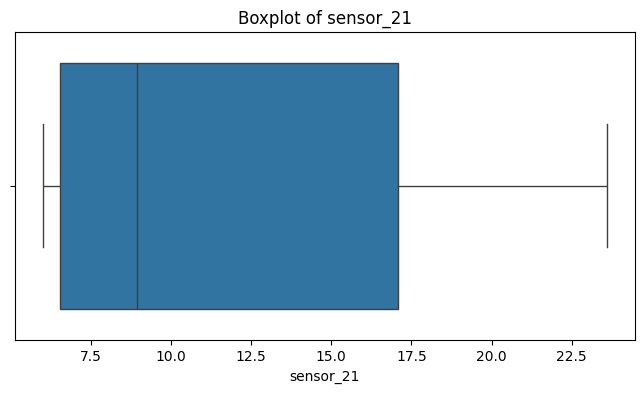

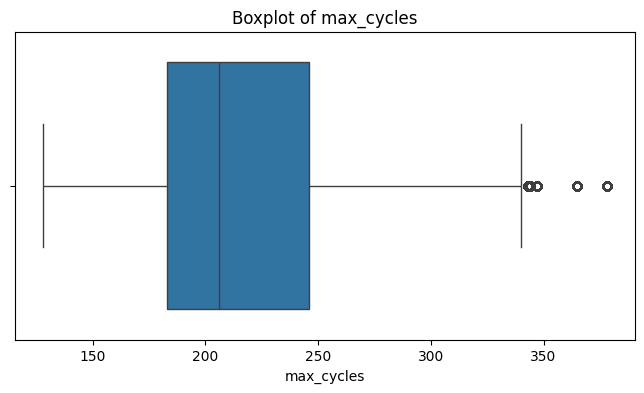

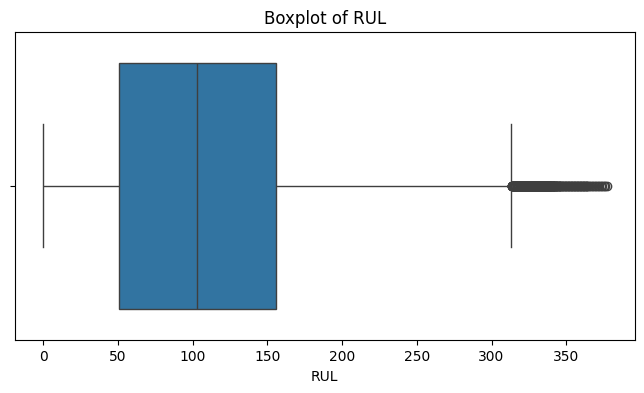

In [ ]:

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
# Check for negative values
for col in num_cols:
    if (df[col] < 0).any():
        print(f"Negative values found in column {col}")


In [ ]:
# Rare categories for numeric columns with few unique values
for col in num_cols:
    if df[col].nunique() < 20:
        value_counts = df[col].value_counts(normalize=True)
        rare = value_counts[value_counts < 0.01]
        if not rare.empty:
            print(f"Rare categories in {col}:")
            print(rare)


Rare categories in sensor_6:
sensor_6
8.01     0.004427
21.60    0.002530
9.04     0.000074
13.67    0.000037
Name: proportion, dtype: float64
Rare categories in sensor_10:
sensor_10
0.93    0.001172
1.25    0.000056
Name: proportion, dtype: float64


In [ ]:
#!pip install ydata-profiling


In [ ]:

# Optional: Automated EDA report using ydata_profiling
''' import ydata_profiling
profile = ydata_profiling.ProfileReport(df)
profile.to_widgets()
profile.to_file("eda_report.html")'''



' import ydata_profiling\nprofile = ydata_profiling.ProfileReport(df)\nprofile.to_widgets()\nprofile.to_file("eda_report.html")'

In [ ]:
# Correlation of numeric features with RUL
correlations = df[num_cols].corr()["RUL"].sort_values(ascending=False)
print("Correlation of numeric features with RUL:")
print(correlations)



Correlation of numeric features with RUL:
RUL              1.000000
max_cycles       0.365136
sensor_20        0.006294
sensor_21        0.006171
sensor_19        0.005757
op_setting_3     0.005757
sensor_13        0.005240
sensor_18        0.004781
sensor_8         0.004345
sensor_10        0.004313
sensor_7         0.002437
sensor_12        0.002255
op_setting_1     0.001127
op_setting_2     0.000038
sensor_1        -0.000014
sensor_6        -0.000489
sensor_5        -0.000750
sensor_2        -0.004922
sensor_9        -0.015300
sensor_3        -0.026936
sensor_17       -0.027026
sensor_15       -0.038455
sensor_4        -0.040972
sensor_14       -0.042323
sensor_11       -0.046946
sensor_16       -0.071345
num_of_cycles   -0.733385
Name: RUL, dtype: float64


#  4-Data Preprocessing

### 1-Train-Test Split

In [ ]:
print("\n" + "="*60)
print("TRAIN-TEST SPLIT (BY ENGINE)")
print("="*60)

# Use the original IDs for splitting
unique_engines = np.sort(engine_ids.unique())
print(f"Total unique engines: {len(unique_engines)}")

# Split: first 80% engines for training, last 20% for testing
split_idx = int(0.8 * len(unique_engines))
train_engines = unique_engines[:split_idx]
test_engines = unique_engines[split_idx:]

# Create train and test datasets
# We need to add engine IDs back to df temporarily
df['temp_engine_id'] = engine_ids.values
train_df = df[df['temp_engine_id'].isin(train_engines)].copy()
test_df = df[df['temp_engine_id'].isin(test_engines)].copy()

# Remove temporary engine ID
train_df = train_df.drop(columns=['temp_engine_id'])
test_df = test_df.drop(columns=['temp_engine_id'])
df = df.drop(columns=['temp_engine_id'])

print(f"Training engines: {len(train_engines)} (IDs: {train_engines[0]} to {train_engines[-1]})")
print(f"Testing engines: {len(test_engines)} (IDs: {test_engines[0]} to {test_engines[-1]})")
print(f"Training rows: {len(train_df)}")
print(f"Testing rows: {len(test_df)}")
print(f"Train class distribution: {train_df['class'].value_counts().to_dict()}")
print(f"Test class distribution: {test_df['class'].value_counts().to_dict()}")

print("Train-Test Split completed successfully")


TRAIN-TEST SPLIT (BY ENGINE)
Total unique engines: 260
Training engines: 208 (IDs: 1 to 208)
Testing engines: 52 (IDs: 209 to 260)
Training rows: 43102
Testing rows: 10656
Train class distribution: {'Healthy': 22094, 'Critical': 10608, 'Warning': 10400}
Test class distribution: {'Healthy': 5404, 'Critical': 2652, 'Warning': 2600}
Train-Test Split completed successfully


### 2-Feature Selection

In [ ]:
print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

# Columns to drop (not useful for modeling)
columns_to_drop = ['id', 'max_cycles']

# Apply to both train and test
train_df_processed = train_df.drop(columns=columns_to_drop, errors='ignore')
test_df_processed = test_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Features after selection:")
print(f"Train shape: {train_df_processed.shape}")
print(f"Test shape: {test_df_processed.shape}")
print(f"Features: {train_df_processed.columns.tolist()}")


FEATURE SELECTION
Features after selection:
Train shape: (43102, 27)
Test shape: (10656, 27)
Features: ['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL', 'class']


###  3- Outlier Detection

In [ ]:
print("\n" + "="*50)
print(" OUTLIER DETECTION")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')  # Don't remove outliers from target
    outliers_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_percentage = (outliers / len(df)) * 100

    if outliers > 0:
        outliers_summary[col] = {
            'outliers': outliers,
            'percentage': outliers_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

print(f"Columns with outliers: {len(outliers_summary)} out of {len(numerical_cols)}")
if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary).T
    print("\nOutliers summary:")
    print(outliers_df[['outliers', 'percentage']].sort_values('percentage', ascending=False).head(10))


 OUTLIER DETECTION
Columns with outliers: 10 out of 26

Outliers summary:
               outliers  percentage
sensor_13        9640.0   17.932215
sensor_14        8049.0   14.972655
sensor_19        8002.0   14.885226
op_setting_3     8002.0   14.885226
sensor_8         8002.0   14.885226
sensor_15        8002.0   14.885226
sensor_18        8002.0   14.885226
sensor_11        3433.0    6.386026
max_cycles       1777.0    3.305555
num_of_cycles     235.0    0.437144


### 3- Handle Outliers

In [ ]:
print("\n" + "="*50)
print("OUTLIER HANDLING")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')

total_outliers = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        print(f"Skipping {col} (constant or near-constant)")
        continue

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    if outliers_before > 0:
        print(f"{col}: {outliers_before} outliers ({outliers_before/len(df)*100:.2f}%)")
        total_outliers += outliers_before
        # Apply capping
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print(f"\nTotal outliers handled: {total_outliers}")
print("="*50)


OUTLIER HANDLING
num_of_cycles: 235 outliers (0.44%)
Skipping op_setting_3 (constant or near-constant)
sensor_8: 8002 outliers (14.89%)
sensor_11: 3433 outliers (6.39%)
sensor_13: 9640 outliers (17.93%)
sensor_14: 8049 outliers (14.97%)
sensor_15: 8002 outliers (14.89%)
sensor_18: 8002 outliers (14.89%)
Skipping sensor_19 (constant or near-constant)
max_cycles: 1777 outliers (3.31%)

Total outliers handled: 47140


### 4-Separating Data

In [ ]:
# Check if variables exist
print(f"train_df_processed exists: {'train_df_processed' in locals()}")
print(f"test_df_processed exists: {'test_df_processed' in locals()}")
print(f"train_df_processed shape: {train_df_processed.shape}")
print(f"test_df_processed shape: {test_df_processed.shape}")

train_df_processed exists: True
test_df_processed exists: True
train_df_processed shape: (43102, 27)
test_df_processed shape: (10656, 27)


In [ ]:
print("\n" + "="*50)
print("SEPARATE DATA FOR DIFFERENT TASKS")
print("="*50)

features = [col for col in train_df_processed.columns if col not in ['RUL', 'class']]

# For CLASSIFICATION
X_train_cls = train_df_processed[features]
y_train_cls = train_df_processed['class']
X_test_cls = test_df_processed[features]
y_test_cls = test_df_processed['class']

# For REGRESSION
X_train_reg = train_df_processed[features]
y_train_reg = train_df_processed['RUL']
X_test_reg = test_df_processed[features]
y_test_reg = test_df_processed['RUL']


SEPARATE DATA FOR DIFFERENT TASKS


### 5-Handle ImBalanced Data(for classification)

In [ ]:
print("\n" + "="*50)
print("HANDLE IMBALANCED CLASS")
print("="*50)

# Encode class labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_cls)
y_test_encoded = label_encoder.transform(y_test_cls)

print(f"Class encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Before SMOTE: {Counter(y_train_encoded)}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_cls, y_train_encoded)

print(f"After SMOTE: {Counter(y_train_balanced)}")
print(f"Training samples increased from {len(X_train_cls):,} to {len(X_train_balanced):,}")


HANDLE IMBALANCED CLASS
Class encoding: {'Critical': np.int64(0), 'Healthy': np.int64(1), 'Warning': np.int64(2)}
Before SMOTE: Counter({np.int64(1): 22094, np.int64(0): 10608, np.int64(2): 10400})
After SMOTE: Counter({np.int64(1): 22094, np.int64(2): 22094, np.int64(0): 22094})
Training samples increased from 43,102 to 66,282


### 6-Feature Scaling

In [ ]:
print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Scale classification data
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_balanced)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# Scale regression data
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Classification data scaled")
print(f"  Train: {X_train_cls_scaled.shape}, Test: {X_test_cls_scaled.shape}")
print("Regression data scaled")
print(f"  Train: {X_train_reg_scaled.shape}, Test: {X_test_reg_scaled.shape}")

# Check scaling
print(f"\nScaling verification (classification data):")
print(f"  Mean ≈ 0: {np.abs(X_train_cls_scaled.mean()).max():.6f}")
print(f"  Std ≈ 1: {np.abs(X_train_cls_scaled.std() - 1).max():.6f}")


FEATURE SCALING
Classification data scaled
  Train: (66282, 25), Test: (10656, 25)
Regression data scaled
  Train: (43102, 25), Test: (10656, 25)

Scaling verification (classification data):
  Mean ≈ 0: 0.000000
  Std ≈ 1: 0.000000


### 7-Final DataFrame

In [ ]:
print("\n" + "="*50)
print("CREATE FINAL DATAFRAMES")
print("="*50)

# Classification datasets
train_cls_final = pd.DataFrame(X_train_cls_scaled, columns=features)
train_cls_final['target'] = y_train_balanced

test_cls_final = pd.DataFrame(X_test_cls_scaled, columns=features)
test_cls_final['target'] = y_test_encoded

# Regression datasets
train_reg_final = pd.DataFrame(X_train_reg_scaled, columns=features)
train_reg_final['RUL'] = y_train_reg.values

test_reg_final = pd.DataFrame(X_test_reg_scaled, columns=features)
test_reg_final['RUL'] = y_test_reg.values

print("✓ Final datasets created")
print(f"  Train classification: {train_cls_final.shape}")
print(f"  Test classification: {test_cls_final.shape}")
print(f"  Train regression: {train_reg_final.shape}")
print(f"  Test regression: {test_reg_final.shape}")


CREATE FINAL DATAFRAMES
✓ Final datasets created
  Train classification: (66282, 26)
  Test classification: (10656, 26)
  Train regression: (43102, 26)
  Test regression: (10656, 26)


### 8-Saving DataSets

In [ ]:
print("\n" + "="*50)
print("SAVE PROCESSED DATASETS")
print("="*50)

# Save all datasets
train_cls_final.to_csv('train_classification.csv', index=False)
test_cls_final.to_csv('test_classification.csv', index=False)
train_reg_final.to_csv('train_regression.csv', index=False)
test_reg_final.to_csv('test_regression.csv', index=False)

# Save metadata
pd.DataFrame({'feature': features}).to_csv('features.csv', index=False)
pd.DataFrame({
    'class': label_encoder.classes_,
    'encoded': label_encoder.transform(label_encoder.classes_)
}).to_csv('class_encoding.csv', index=False)

print("Files saved:")
print("  • train_classification.csv")
print("  • test_classification.csv")
print("  • train_regression.csv")
print("  • test_regression.csv")
print("  • features.csv")
print("  • class_encoding.csv")


SAVE PROCESSED DATASETS
Files saved:
  • train_classification.csv
  • test_classification.csv
  • train_regression.csv
  • test_regression.csv
  • features.csv
  • class_encoding.csv


###9-Summary

In [ ]:
print("\n" + "="*50)
print("PREPROCESSING COMPLETE - READY FOR MODELING")
print("="*50)

print("\nDATA OVERVIEW:")
print(f"  • Original data: {df.shape[0]:,} samples, {df.shape[1]} columns")
print(f"  • Engines: {len(unique_engines)} total, {len(train_engines)} train, {len(test_engines)} test")

print("\n TARGETS:")
print(f"  • RUL range: {df['RUL'].min()} to {df['RUL'].max()}")
print(f"  • Classes: Healthy (>100), Warning (51-100), Critical (0-50)")

print("\nPREPROCESSING STEPS APPLIED:")
print("  1. Time series split by engine")
print("  2. Feature selection (removed id, max_cycles)")
print("  3. Outlier detection & capping (IQR method)")
print("  4. Separate datasets for classification & regression")
print("  5. Class balancing with SMOTE (classification only)")
print("  6. Feature scaling (Standardization)")

print("\nFINAL DATASETS:")
print(f"  Classification - Train: {train_cls_final.shape}, Test: {test_cls_final.shape}")
print(f"  Regression - Train: {train_reg_final.shape}, Test: {test_reg_final.shape}")

print("\n" + "="*50)
print("USAGE:")
print("="*50)
print("""
# Load classification data:
train_cls = pd.read_csv('train_classification.csv')
test_cls = pd.read_csv('test_classification.csv')
X_train_cls = train_cls.drop('target', axis=1)
y_train_cls = train_cls['target']

# Load regression data:
train_reg = pd.read_csv('train_regression.csv')
test_reg = pd.read_csv('test_regression.csv')
X_train_reg = train_reg.drop('RUL', axis=1)
y_train_reg = train_reg['RUL']
""")


PREPROCESSING COMPLETE - READY FOR MODELING

DATA OVERVIEW:
  • Original data: 53,758 samples, 28 columns
  • Engines: 260 total, 208 train, 52 test

 TARGETS:
  • RUL range: 0 to 377
  • Classes: Healthy (>100), Warning (51-100), Critical (0-50)

PREPROCESSING STEPS APPLIED:
  1. Time series split by engine
  2. Feature selection (removed id, max_cycles)
  3. Outlier detection & capping (IQR method)
  4. Separate datasets for classification & regression
  5. Class balancing with SMOTE (classification only)
  6. Feature scaling (Standardization)

FINAL DATASETS:
  Classification - Train: (66282, 26), Test: (10656, 26)
  Regression - Train: (43102, 26), Test: (10656, 26)

USAGE:

# Load classification data:
train_cls = pd.read_csv('train_classification.csv')
test_cls = pd.read_csv('test_classification.csv')
X_train_cls = train_cls.drop('target', axis=1)
y_train_cls = train_cls['target']

# Load regression data:
train_reg = pd.read_csv('train_regression.csv')
test_reg = pd.read_csv('tes

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Define columns to exclude
# We exclude RUL (target), noise sensors, and any previous prediction columns
noise_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
extra_cols = ['RUL', 'y_pred', 'regime'] # Columns that might exist from previous runs

# 2. Prepare X_train and y_train
# Using errors='ignore' ensures it doesn't crash if 'y_pred' isn't there yet
X_train_final = train_reg_final.drop(columns=extra_cols + noise_sensors, errors='ignore')
y_train_final = train_reg_final['RUL']

# 3. Prepare X_test and y_test
# We must drop the exact same columns as the training set
X_test_final = test_reg_final.drop(columns=extra_cols + noise_sensors, errors='ignore')
y_test_final = test_reg_final['RUL']

# 4. Initialize and Train
rf_regressor = RandomForestRegressor(
    n_estimators=250,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train_final, y_train_final)

# 5. Predict
y_pred_reg = rf_regressor.predict(X_test_final)

# 6. Evaluate
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_reg))
mae = mean_absolute_error(y_test_final, y_pred_reg)


print("="*60)
print("FINAL RANDOM FOREST REGRESSION RESULTS (RAW DATA)")
print("="*60)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cycles")
print(f"Mean Absolute Error (MAE): {mae:.2f} cycles")
print(f"R-squared Score (R2): {r2:.4f}")
print("="*60)

FINAL RANDOM FOREST REGRESSION RESULTS (RAW DATA)
Root Mean Squared Error (RMSE): 36.95 cycles
Mean Absolute Error (MAE): 27.40 cycles
R-squared Score (R2): 0.7125


CLASSIFICATION PERFORMANCE BASED ON REGRESSION
Accuracy Score: 0.8407
------------------------------------------------------------
              precision    recall  f1-score   support

    Critical       0.91      0.77      0.83      1612
     Healthy       0.88      0.94      0.91      6704
     Warning       0.66      0.59      0.62      2340

    accuracy                           0.84     10656
   macro avg       0.81      0.77      0.79     10656
weighted avg       0.84      0.84      0.84     10656



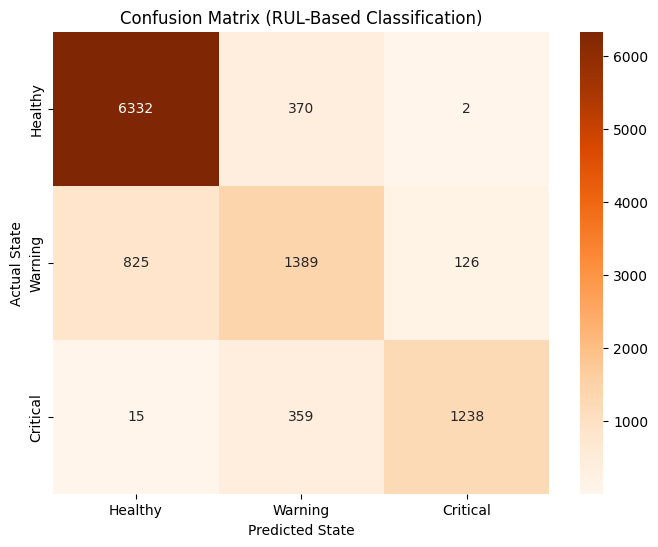

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def r_to_c(rul):
    if rul <= 30:
        return 'Critical'
    elif rul <= 75:
        return 'Warning'
    else:
        return 'Healthy'

y_test_class = [r_to_c(val) for val in y_test_final]
y_pred_class = [r_to_c(val) for val in y_pred_reg]

print("="*60)
print("CLASSIFICATION PERFORMANCE BASED ON REGRESSION")
print("="*60)
print(f"Accuracy Score: {accuracy_score(y_test_class, y_pred_class):.4f}")
print("-" * 60)
print(classification_report(y_test_class, y_pred_class))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, y_pred_class, labels=['Healthy', 'Warning', 'Critical'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Warning', 'Critical'],
            yticklabels=['Healthy', 'Warning', 'Critical'])
plt.title('Confusion Matrix (RUL-Based Classification)')
plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.show()

In [ ]:
import joblib
joblib.dump(rf_regressor, 'rf_model.pkl')

['rf_model.pkl']

In [ ]:
df.to_csv('processed_test_data.csv', index=False)

In [ ]:
print(df.columns)

Index(['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL', 'class'],
      dtype='object')


In [ ]:
!pip install -q streamlit pyngrok


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- High-Level System Configuration ---
st.set_page_config(
    page_title="AeroHealth Pro | Industrial Intelligence",
    page_icon="🛡️",
    layout="wide"
)

# --- Professional High-Contrast CSS ---
st.markdown("""
    <style>
    [data-testid="stMetricValue"] {
        color: #002D62 !important;
        font-weight: 800 !important;
        font-size: 2.2rem !important;
    }
    [data-testid="stMetricLabel"] {
        color: #1C1C1E !important;
        font-weight: 600 !important;
        font-size: 1rem !important;
    }
    [data-testid="stMetric"] {
        background-color: #FFFFFF !important;
        border: 2px solid #0047AB !important;
        border-radius: 12px !important;
        padding: 15px !important;
        box-shadow: 0 4px 10px rgba(0,0,0,0.1) !important;
    }
    .stTabs [data-baseweb="tab-list"] { gap: 10px; }
    .stTabs [data-baseweb="tab"] {
        background-color: #f1f3f5; border-radius: 5px; padding: 10px 20px; font-weight: bold; color: #495057;
    }
    .stTabs [aria-selected="true"] { background-color: #0047AB !important; color: white !important; }
    .insight-card {
        background-color: #eef4ff; padding: 20px; border-radius: 10px; border-left: 6px solid #0047AB; margin-bottom: 25px;
    }
    </style>
    """, unsafe_allow_html=True)

# --- Asset & Model Loader ---
@st.cache_resource
def load_phm_engine():
    # Load your specific model and scaler
    model = joblib.load('rf_model.pkl')

    # Standardized NASA C-MAPSS Feature Set
    features = [
        'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
        'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
        'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
        'sensor_17', 'sensor_20', 'sensor_21'
    ]
    return model, features

model, training_features = load_phm_engine()

# --- Sidebar Control Panel ---
with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/725/725107.png", width=80)
    st.title("AeroHealth Pro")
    st.caption("Prognostics & Health Management (PHM) System")
    st.divider()
    uploaded_file = st.file_uploader("📥 Synchronize Telemetry Data", type=['csv'])
    st.divider()
    if uploaded_file:
        st.success("✅ Telemetry Stream Active")
    else:
        st.info("Awaiting CSV input...")

# --- Main Dashboard Logic ---
st.title("✈️ Fleet Reliability & RUL Analytics")

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)
    id_col = data.columns[0]

    # --- HANDLING SCALING ---
    # Apply StandardScaler to features before prediction
    scaler_reg = StandardScaler()
    X_raw = data[training_features]
    X_scaled = scaler_reg.fit_transform(X_raw)

    # AI Engine Inference
    raw_predictions = model.predict(X_scaled)

    # IMPORTANT: If your target (RUL) was also scaled during training,
    # you would need to inverse_transform it here.
    # If not, we ensure it's a realistic positive integer.
    data['Predicted_RUL'] = np.maximum(0, raw_predictions).astype(int)

    data['Status'] = data['Predicted_RUL'].apply(
        lambda x: '🚨 Critical' if x <= 30 else ('⚠️ Warning' if x <= 75 else '✅ Healthy')
    )

    # --- TOP LEVEL KPI SCORECARDS ---
    fleet_latest = data.groupby(id_col).tail(1)
    k1, k2, k3, k4 = st.columns(4)

    k1.metric("Assets Active", f"{len(fleet_latest)}")
    k2.metric("Mean RUL (Fleet)", f"{fleet_latest['Predicted_RUL'].mean():.0f} Cyc")
    k3.metric("Critical Alerts", f"{len(fleet_latest[fleet_latest['Status'].str.contains('Critical')])}")
    k4.metric("Reliability Index", f"{(len(fleet_latest[fleet_latest['Status'].str.contains('Healthy')]) / len(fleet_latest) * 100):.1f}%")

    st.divider()

    tab_fleet, tab_diagnostics, tab_sensors = st.tabs(["🌐 Fleet Risk Portfolio", "🔬 Asset Digital Twin", "⚙️ Sensor Sensitivity"])

    # TAB 1: MACRO FLEET PORTFOLIO
    with tab_fleet:
        st.markdown("<div class='insight-card'><b>Fleet Intelligence Summary:</b> Analyze life expectancy distribution across all units.</div>", unsafe_allow_html=True)
        c1, c2 = st.columns([1, 1.2])
        with c1:
            st.write("### Risk Classification")
            fig_pie = px.pie(fleet_latest, names='Status', hole=0.55,
                             color='Status', color_discrete_map={'✅ Healthy':'#2ecc71', '⚠️ Warning':'#f1c40f', '🚨 Critical':'#e74c3c'})
            st.plotly_chart(fig_pie, use_container_width=True)
        with c2:
            st.write("### Fleet Life Expectancy")
            fig_hist = px.histogram(fleet_latest, x="Predicted_RUL", nbins=20,
                                    color_discrete_sequence=['#0047AB'], labels={'Predicted_RUL':'Cycles to Failure'})
            st.plotly_chart(fig_hist, use_container_width=True)

    # TAB 2: DIGITAL TWIN DIAGNOSTICS
    with tab_diagnostics:
        col_ctrl, col_chart = st.columns([1, 2.2])
        with col_ctrl:
            selected_id = st.selectbox("Select Asset Serial Number", data[id_col].unique())
            unit_data = data[data[id_col] == selected_id]
            curr_val = unit_data['Predicted_RUL'].iloc[-1]
            curr_stat = unit_data['Status'].iloc[-1]

            st.write(f"### Diagnosis: Unit {selected_id}")
            if "Critical" in curr_stat:
                st.error(f"⚠️ **IMMEDIATE GROUNDING:** RUL at {curr_val} cycles.")
            elif "Warning" in curr_stat:
                st.warning(f"🔧 **PREVENTIVE ACTION:** Maintenance required soon.")
            else:
                st.success("✔️ **OPERATIONAL:** Asset is fit for flight.")

            fig_gauge = go.Figure(go.Indicator(
                mode = "gauge+number",
                value = curr_val,
                gauge = {
                    'axis': {'range': [0, 250]},
                    'bar': {'color': "#0047AB"},
                    'steps': [
                        {'range': [0, 30], 'color': "#f8d7da"},
                        {'range': [30, 75], 'color': "#fff3cd"},
                        {'range': [75, 250], 'color': "#d4edda"}]
                }
            ))
            st.plotly_chart(fig_gauge, use_container_width=True)

        with col_chart:
            st.write("### Degradation Trajectory")
            st.caption("Standardized RUL degradation profile over flight cycles.")

            fig_trend = px.line(unit_data, x='num_of_cycles', y='Predicted_RUL',
                                labels={'num_of_cycles':'Cycles Completed', 'Predicted_RUL':'Real-Time RUL'})
            fig_trend.update_traces(line_color='#0047AB', line_width=4)
            st.plotly_chart(fig_trend, use_container_width=True)

    # TAB 3: EXPLAINABLE AI (XAI)
    with tab_sensors:
        st.markdown("<div class='insight-card'><b>Explainable AI (XAI):</b> Statistical weight of sensors on the RUL prediction outcome.</div>", unsafe_allow_html=True)
        c_top, c_desc = st.columns([1.5, 1])
        with c_top:
            st.write("### Global Feature Importance")
            importances = model.feature_importances_
            feat_df = pd.DataFrame({'Sensor': training_features, 'Impact': importances}).sort_values('Impact', ascending=True)
            fig_imp = px.bar(feat_df, x='Impact', y='Sensor', orientation='h',
                             color='Impact', color_continuous_scale='Blues')
            st.plotly_chart(fig_imp, use_container_width=True)
        with c_desc:
            st.write("### Critical Telemetry Key")
            st.write("""
            - **Pressure Sensors:** High sensitivity to compression loss.
            - **Temperature Sensors:** Indicators of thermal bypass or combustion wear.
            - **Rotational Speed:** Direct correlation with mechanical friction.
            """)

else:
    st.image("https://images.unsplash.com/photo-1544724569-5f546fd6f2b5?auto=format&fit=crop&q=80&w=2000", caption="Industrial PHM Platform", use_column_width=True)
    st.warning("🛡️ Please upload engine telemetry CSV via the sidebar to begin analysis.")

Overwriting app.py


In [ ]:
!pkill -f streamlit
!pkill -f ngrok


In [ ]:
# 1. Install pyngrok
!pip install -q pyngrok

from pyngrok import ngrok
import os
import time

# 2. Add your token
NGROK_AUTH_TOKEN = "37RCpVp8dI7EBvLx0aK8VnGQsVM_7sQiNYYEsqs5Bff9dWDu7"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("Cleaning up existing sessions...")
tunnels = ngrok.get_tunnels()
for tunnel in tunnels:
    ngrok.disconnect(tunnel.public_url)
ngrok.kill()

time.sleep(1)

# 4. Run Streamlit in background
os.system("streamlit run app.py &")

# 5. Create Tunnel
try:
    # public_url = ngrok.connect(8501, domain="nonevolutionally-presacrificial-charline.ngrok-free.dev")

    public_url = ngrok.connect(8501)
    print("\n" + "="*50)
    print("Your App is live at:", public_url)
    print("="*50)
except Exception as e:
    print("Error starting ngrok:", e)

Cleaning up existing sessions...


Error starting ngrok: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://nonevolutionally-presacrificial-charline.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}



app.py			 rf_model.pkl		  test_regression.csv
class_encoding.csv	 sample_data		  train_classification.csv
features.csv		 streamlit_logs.txt	  train_FD002.csv
processed_test_data.csv  test_classification.csv  train_regression.csv


In [ ]:
python -m streamlit run app.py